# NVDA–TSLA Spread Prediction, Validation Tuning, and Long–Short Backtest

This notebook is the updated end-to-end runner for the project. It does five things in order:

1. inspects the raw `mag7.pickle` data and the engineered NVDA–TSLA pair dataset,
2. visualizes prices, returns, and the realized spread over the full sample,
3. documents the model, target, feature, rolling-window, and validation-tuning design,
4. runs all four models with rolling-window validation-based hyperparameter selection,
5. evaluates both model fit and portfolio performance against benchmarks.

This notebook assumes you have already replaced the `src/` modules with the **validation-tuned rolling-window pipeline** so that `run_all_experiments()` returns:

- `dataset`
- `windows`
- `tuning_summary`
- `best_params_summary`
- `predictions`
- `classification_summary`
- `confusion_summary`
- `portfolio_summary`
- `relative_summary`
- `coefficient_summary`


In [1]:
from pathlib import Path
import sys
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

warnings.filterwarnings("ignore")

ROOT = Path.cwd().resolve()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent

if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 180)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

from src import config
from src.data import load_raw_data, filter_pair, add_daily_returns
from src.features import add_accounting_features, add_technical_features, build_pair_dataset
from src.engine import make_dataset, build_rolling_windows, run_all_experiments
from src.backtest import wealth_index

print("ROOT =", ROOT)
print("Raw data path =", config.RAW_DATA_PATH)

ROOT = /Users/jimmyzheng0516/Desktop/Course-Winter-2026/FINM33160/ML-Group-Project
Raw data path = /Users/jimmyzheng0516/Desktop/Course-Winter-2026/FINM33160/ML-Group-Project/data/raw/mag7.pickle


## 1. Load and inspect the data

In [2]:
raw = load_raw_data(config.RAW_DATA_PATH)

pair_raw = filter_pair(raw, config.SYMBOL_A, config.SYMBOL_B).copy()
pair_raw = add_daily_returns(pair_raw)

pair_features = add_accounting_features(pair_raw.copy())
pair_features = add_technical_features(pair_features)

pair_dataset = build_pair_dataset(pair_features, config.SYMBOL_A, config.SYMBOL_B)

summary = pd.DataFrame({
    "stat": [
        "raw rows",
        "raw cols",
        "pair raw rows",
        "pair raw cols",
        "pair dataset rows",
        "pair dataset cols",
        "start date",
        "end date",
    ],
    "value": [
        raw.shape[0],
        raw.shape[1],
        pair_raw.shape[0],
        pair_raw.shape[1],
        pair_dataset.shape[0],
        pair_dataset.shape[1],
        pair_dataset["date"].min(),
        pair_dataset["date"].max(),
    ],
})

display(summary)

,stat,value
0,raw rows,27391
1,raw cols,93
2,pair raw rows,7928
3,pair raw cols,94
4,pair dataset rows,3839
5,pair dataset cols,21
6,start date,2010-09-28 00:00:00
7,end date,2025-12-30 00:00:00


In [3]:
coverage = (
    pair_raw.groupby("symbol")
    .agg(
        n_obs=("date", "size"),
        start_date=("date", "min"),
        end_date=("date", "max"),
        min_close=("close_adj", "min"),
        max_close=("close_adj", "max"),
        mean_daily_return=("ret_1d", "mean"),
        daily_volatility=("ret_1d", "std"),
    )
    .reset_index()
)

display(coverage)
display(pair_raw.head())
display(pair_dataset.head())

,symbol,n_obs,start_date,end_date,min_close,max_close,mean_daily_return,daily_volatility
0,NVDA,4025,2010-01-04,2025-12-31,0.2221,207.0290,0.0019,0.0288
1,TSLA,3903,2010-06-29,2025-12-31,1.0533,489.8800,0.0021,0.0364


,symbol,date,close_adj,volume,datadate,actq,ajexq,atq,capxy,ceqq,chechy,cheq,cogsq,cogsy,csh12q,cshfdq,cshiq,cshopq,cshoq,cshprq,cstkq,curcdq,datacqtr,datafqtr,dlcq,dltisy,dltry,dlttq,dpcy,dpq,dvpq,dvpspq,dvy,epsf12,epsfi12,epsfiq,epsfxq,epspi12,epspiq,epspxq,epsx12,fqtr,fyearq,fyr,ibadjq,ibcomq,ibcomy,ibcy,ibq,icaptq,invtq,lctq,ltq,mibq,miiq,miiy,niq,nopiq,oancfy,oepf12,oeps12,oepsxq,oepsxy,oiadpq,oiadpy,oibdpq,oibdpy,piq,ppentq,pstkq,pstkrq,rectq,req,revtq,revty,saleq,seqq,spiq,teqq,txdbq,txditcq,txpdy,txpq,txtq,xidocy,xidoy,xintq,xinty,xoprq,xrdq,xrdy,xsgaq,xsgay,ret_1d
0,NVDA,2010-01-04,0.4622,"20,156,410.0000",2009-10-31,"2,357.7160",40.0000,"3,463.5740",55.0260,"2,423.6350",196.8020,"1,634.0790",535.5380,"1,498.4650",544.4515,574.3810,645.8260,0.0000,554.9000,551.2830,0.6460,USD,2009Q3,2009Q3,0.9280,0.0000,0.0000,24.7600,148.7500,48.7700,0.0000,0.0000,0.0000,-0.6300,-0.6300,0.1900,0.1900,-0.6300,0.2000,0.2000,-0.6300,3,2009,1,107.5770,107.5770,-199.0630,-199.0630,107.5770,"2,448.3950",277.6430,888.8060,"1,039.9390",0.0000,0.0000,0.0000,107.5770,2.3620,418.5620,-0.2900,-0.2900,0.1400,-0.0300,82.7400,0.9630,131.5100,149.7130,110.2070,565.2960,0.0000,0.0000,397.8200,"1,774.7510",903.2060,"2,343.9570",903.2060,"2,423.6350",25.1050,"2,423.6350",0.0000,57.0530,2.6110,0.0000,2.6300,0.0000,0.0000,0.0540,0.0540,771.6960,197.9480,692.6000,236.1580,695.7790,<NA>
1,NVDA,2010-01-05,0.4690,"18,292,140.0000",2009-10-31,"2,357.7160",40.0000,"3,463.5740",55.0260,"2,423.6350",196.8020,"1,634.0790",535.5380,"1,498.4650",544.4515,574.3810,645.8260,0.0000,554.9000,551.2830,0.6460,USD,2009Q3,2009Q3,0.9280,0.0000,0.0000,24.7600,148.7500,48.7700,0.0000,0.0000,0.0000,-0.6300,-0.6300,0.1900,0.1900,-0.6300,0.2000,0.2000,-0.6300,3,2009,1,107.5770,107.5770,-199.0630,-199.0630,107.5770,"2,448.3950",277.6430,888.8060,"1,039.9390",0.0000,0.0000,0.0000,107.5770,2.3620,418.5620,-0.2900,-0.2900,0.1400,-0.0300,82.7400,0.9630,131.5100,149.7130,110.2070,565.2960,0.0000,0.0000,397.8200,"1,774.7510",903.2060,"2,343.9570",903.2060,"2,423.6350",25.1050,"2,423.6350",0.0000,57.0530,2.6110,0.0000,2.6300,0.0000,0.0000,0.0540,0.0540,771.6960,197.9480,692.6000,236.1580,695.7790,0.0146
2,NVDA,2010-01-06,0.4720,"16,315,670.0000",2009-10-31,"2,357.7160",40.0000,"3,463.5740",55.0260,"2,423.6350",196.8020,"1,634.0790",535.5380,"1,498.4650",544.4515,574.3810,645.8260,0.0000,554.9000,551.2830,0.6460,USD,2009Q3,2009Q3,0.9280,0.0000,0.0000,24.7600,148.7500,48.7700,0.0000,0.0000,0.0000,-0.6300,-0.6300,0.1900,0.1900,-0.6300,0.2000,0.2000,-0.6300,3,2009,1,107.5770,107.5770,-199.0630,-199.0630,107.5770,"2,448.3950",277.6430,888.8060,"1,039.9390",0.0000,0.0000,0.0000,107.5770,2.3620,418.5620,-0.2900,-0.2900,0.1400,-0.0300,82.7400,0.9630,131.5100,149.7130,110.2070,565.2960,0.0000,0.0000,397.8200,"1,774.7510",903.2060,"2,343.9570",903.2060,"2,423.6350",25.1050,"2,423.6350",0.0000,57.0530,2.6110,0.0000,2.6300,0.0000,0.0000,0.0540,0.0540,771.6960,197.9480,692.6000,236.1580,695.7790,0.0064
3,NVDA,2010-01-07,0.4628,"13,796,019.0000",2009-10-31,"2,357.7160",40.0000,"3,463.5740",55.0260,"2,423.6350",196.8020,"1,634.0790",535.5380,"1,498.4650",544.4515,574.3810,645.8260,0.0000,554.9000,551.2830,0.6460,USD,2009Q3,2009Q3,0.9280,0.0000,0.0000,24.7600,148.7500,48.7700,0.0000,0.0000,0.0000,-0.6300,-0.6300,0.1900,0.1900,-0.6300,0.2000,0.2000,-0.6300,3,2009,1,107.5770,107.5770,-199.0630,-199.0630,107.5770,"2,448.3950",277.6430,888.8060,"1,039.9390",0.0000,0.0000,0.0000,107.5770,2.3620,418.5620,-0.2900,-0.2900,0.1400,-0.0300,82.7400,0.9630,131.5100,149.7130,110.2070,565.2960,0.0000,0.0000,397.8200,"1,774.7510",903.2060,"2,343.9570",903.2060,"2,423.6350",25.1050,"2,423.6350",0.0000,57.0530,2.6110,0.0000,2.6300,0.0000,0.0000,0.0540,0.0540,771.6960,197.9480,692.6000,236.1580,695.7790,-0.0196
4,NVDA,2010-01-08,0.4637,"12,061,066.0000",2009-10-31,"2,357.7160",40.0000,"3,463.5740",55.0260,"2,423.6350",196.8020,"1,634.0790",535.5380,"1,498.4650",544.4515,574.3810,645.8260,0.0000,554.9000,551.2830,0.6460,U

,date,ret_a_next,ret_b_next,spread_t,spread_next,op_margin_diff,net_margin_diff,leverage_diff,cash_ratio_diff,rnd_intensity_diff,capex_intensity_diff,asset_turnover_diff,log_mcap_diff,mom5_diff,mom21_diff,mom63_diff,ma_gap20_diff,rsi14_diff,rv21_diff,vol_shock20_diff,y_binary
0,2010-09-28,-0.0076,0.0271,-0.0444,-0.0347,1.1271,1.1822,-0.3066,0.1554,-0.2831,-0.1048,0.0254,0.2562,0.0300,0.0966,0.2465,0.0876,24.9394,-0.0396,-0.6863,0
1,2010-09-29,-0.0167,-0.0717,-0.0347,0.0550,1.1271,1.1822,-0.3066,0.1554,-0.2831,-0.1048,0.0254,0.2218,-0.0632,0.1262,0.2412,0.0441,22.0264,-0.0902,-0.7517,1
2,2010-09-30,-0.0284,0.0096,0.0550,-0.0380,1.1271,1.1822,-0.3066,0.1554,-0.2831,-0.1048,0.0254,0.2793,-0.0379,0.2053,0.1962,0.0901,25.6947,-0.1717,-0.9633,0
3,2010-10-01,-0.0097,0.0189,-0.0380,-0.0286,1.1271,1.1822,-0.3066,0.1554,-0.2831,-0.1048,0.0254,0.2410,-0.0991,0.2000,0.0344,0.0407,13.4926,-0.1212,0.5376,0
4,2010-10-04,0.0071,0.0062,-0.0286,0.0009,1.1271,1.1822,-0.3066,0.1554,-0.2831,-0.1048,0.0254,0.2125,-0.0853,0.1778,-0.1944,0.0055,13.3189,-0.1110,0.1803,1


In [4]:
missing_pair = pair_dataset.isna().sum().sort_values(ascending=False)
display(missing_pair[missing_pair > 0].to_frame("n_missing"))

,n_missing


### Basic price and return visualization

The first figure shows the raw adjusted price paths and daily returns for NVDA and TSLA.  
The second figure focuses on the realized daily spread $s_t$ and its distribution over the full sample.


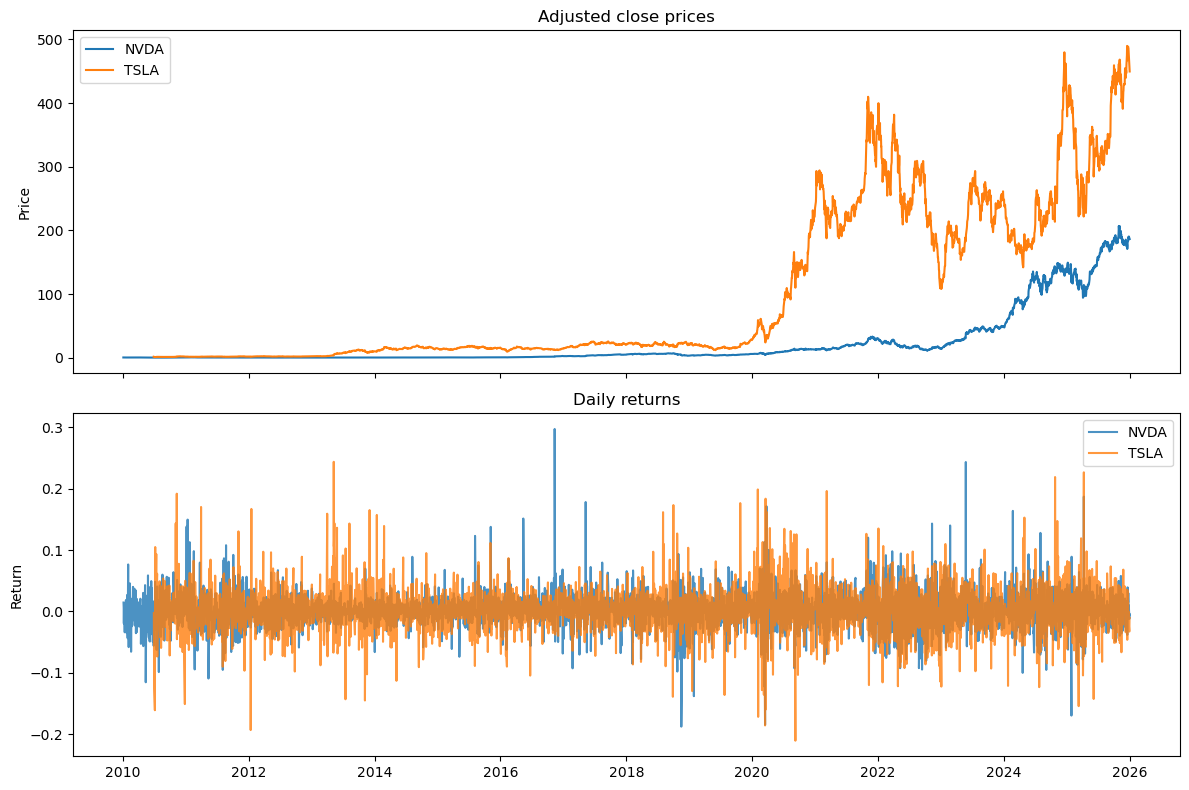

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

for symbol, sub in pair_raw.groupby("symbol"):
    sub = sub.sort_values("date")
    axes[0].plot(sub["date"], sub["close_adj"], label=symbol)
    axes[1].plot(sub["date"], sub["ret_1d"], label=symbol, alpha=0.8)

axes[0].set_title("Adjusted close prices")
axes[0].set_ylabel("Price")
axes[0].legend()

axes[1].set_title("Daily returns")
axes[1].set_ylabel("Return")
axes[1].legend()

plt.tight_layout()
plt.show()

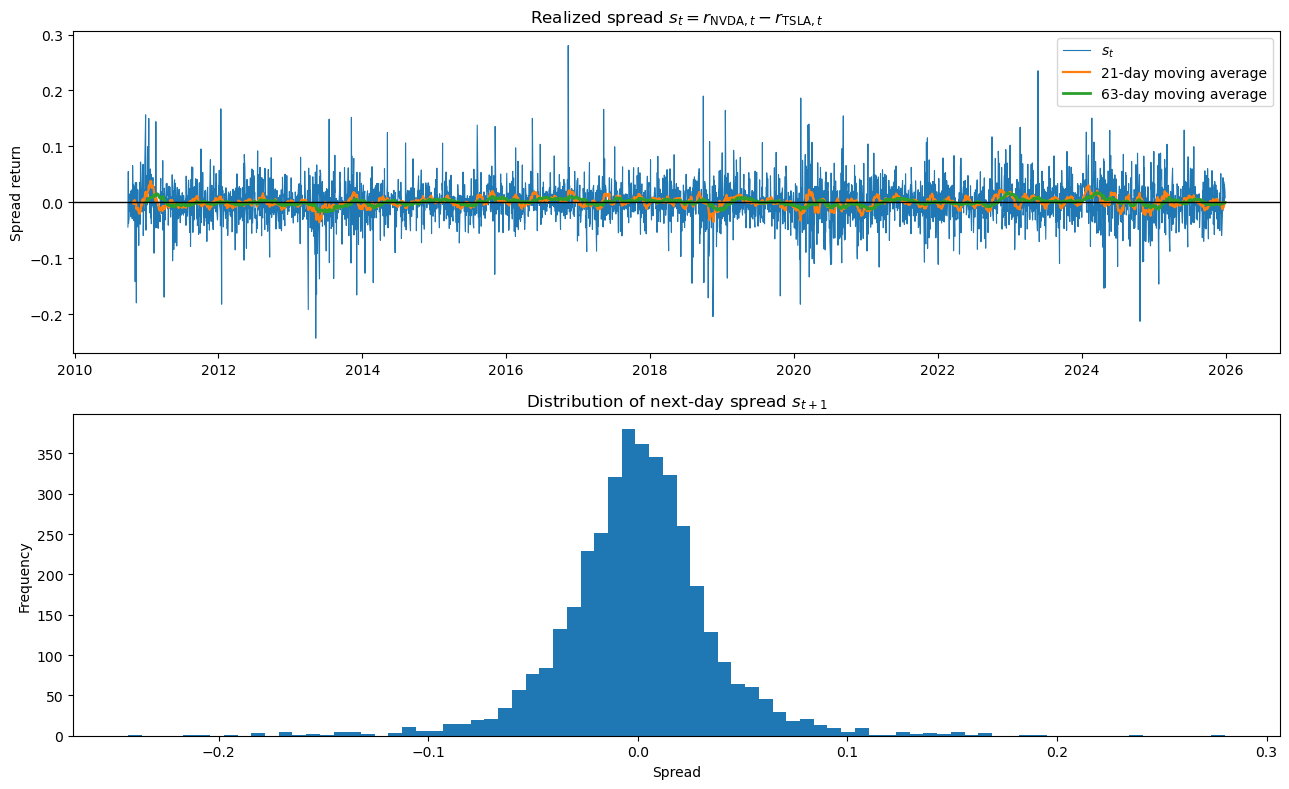

In [6]:
spread_plot = pair_dataset[["date", "spread_t", "spread_next"]].copy()
spread_plot["spread_t_21d_ma"] = spread_plot["spread_t"].rolling(21).mean()
spread_plot["spread_t_63d_ma"] = spread_plot["spread_t"].rolling(63).mean()

fig, axes = plt.subplots(2, 1, figsize=(13, 8))

axes[0].plot(spread_plot["date"], spread_plot["spread_t"], linewidth=0.8, label=r"$s_t$")
axes[0].plot(spread_plot["date"], spread_plot["spread_t_21d_ma"], linewidth=1.6, label="21-day moving average")
axes[0].plot(spread_plot["date"], spread_plot["spread_t_63d_ma"], linewidth=2.0, label="63-day moving average")
axes[0].axhline(0.0, color="black", linewidth=1)
axes[0].set_title(r"Realized spread $s_t = r_{\mathrm{NVDA},t} - r_{\mathrm{TSLA},t}$")
axes[0].set_ylabel("Spread return")
axes[0].legend()

axes[1].hist(spread_plot["spread_next"].dropna(), bins=80)
axes[1].set_title(r"Distribution of next-day spread $s_{t+1}$")
axes[1].set_xlabel("Spread")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

In [7]:
sign_table = pd.DataFrame({
    "count": pair_dataset["y_binary"].value_counts().sort_index(),
})
sign_table.index = ["spread_next <= 0", "spread_next > 0"]
sign_table["share"] = sign_table["count"] / sign_table["count"].sum()

display(sign_table)
display(pair_dataset[["spread_t", "spread_next"]].describe().T)

,count,share
spread_next <= 0,1909,0.4973
spread_next > 0,1930,0.5027


,count,mean,std,min,25%,50%,75%,max
spread_t,"3,839.0000",-0.0001,0.0368,-0.2432,-0.0187,0.0002,0.0187,0.2802
spread_next,"3,839.0000",-0.0001,0.0368,-0.2432,-0.0186,0.0002,0.0187,0.2802


## 2. Model, target, feature, rolling-window, and validation-tuning specification

### 2.1 Daily return and spread

Let $P_{i,t}$ be the adjusted close of stock $i$ on day $t$. Daily return is

$$
r_{i,t}=
rac{P_{i,t}}{P_{i,t-1}}-1.
$$

For the stock pair $(\mathrm{NVDA}, \mathrm{TSLA})$, define the realized spread

$$
s_t=r_{\mathrm{NVDA},t}-r_{\mathrm{TSLA},t}.
$$

The prediction target is based on the next-day spread $s_{t+1}$.

### 2.2 Binary target and binary trading signal

For the binary models,

$$
y^{\mathrm{bin}}_t=\mathbf{1}\{s_{t+1}>0\}.
$$

Both binary logistic regression and the binary neural network output a probability

$$
\hat p_t = \Pr\left(y^{\mathrm{bin}}_t=1\mid x_t\right).
$$

The binary trading signal is then

$$
d_t=
\begin{cases}
1, & \hat p_t>0.5,\\
0, & \hat p_t=0.5,\\
-1, & \hat p_t<0.5.
\end{cases}
$$

### 2.3 Multiclass target and multiclass trading signal

For the multiclass models, the target has three classes:

- $1$: sufficiently positive spread tomorrow,
- $0$: small or neutral spread tomorrow,
- $-1$: sufficiently negative spread tomorrow.

For a candidate quantile $\tau$, define the threshold from the train sample in a given rolling window:

$$
q^{(w)}(\tau)=\mathrm{Quantile}_{\tau}\left(\left|s_{t+1}\right|: t \in \mathcal{T}^{(w)}_{\mathrm{train}}\right).
$$

Then the multiclass target is

$$
y^{\mathrm{multi}}_t=
\begin{cases}
1, & s_{t+1} \ge q^{(w)}(\tau),\\
-1, & s_{t+1} \le -q^{(w)}(\tau),\\
0, & \left|s_{t+1}\right|<q^{(w)}(\tau).
\end{cases}
$$

The multiclass model outputs three probabilities,

$$
\Pr(y_t=-1\mid x_t), \qquad \Pr(y_t=0\mid x_t), \qquad \Pr(y_t=1\mid x_t),
$$

and predicts the most likely class:

$$
\hat y_t = \arg\max_{c\in\{-1,0,1\}} \Pr(y_t=c\mid x_t).
$$

The multiclass trading signal is simply

$$
d_t=\hat y_t\in\{-1,0,1\}.
$$

### 2.4 Feature construction

Each feature is a cross-sectional difference between NVDA and TSLA:

$$
x_{k,t}=f_{k,\mathrm{NVDA},t}-f_{k,\mathrm{TSLA},t}.
$$

The accounting features are based on:

- operating margin
$$
\mathrm{op\_margin}=\frac{\mathrm{oiadpq}}{\mathrm{saleq}}
$$

- net margin
$$
\mathrm{net\_margin}=\frac{\mathrm{niq}}{\mathrm{saleq}}
$$

- leverage
$$
\mathrm{leverage}=\frac{\mathrm{dlttq}+\mathrm{dlcq}}{\mathrm{atq}}
$$

- cash ratio
$$
\mathrm{cash\_ratio}=\frac{\mathrm{cheq}}{\mathrm{atq}}
$$

- R\&D intensity
$$
\mathrm{rnd\_intensity}=\frac{\mathrm{xrdq}}{\mathrm{saleq}}
$$

- capex intensity
$$
\mathrm{capex\_intensity}=\frac{\mathrm{capxy}}{\mathrm{atq}}
$$

- asset turnover
$$
\mathrm{asset\_turnover}=\frac{\mathrm{saleq}}{\mathrm{atq}}
$$

- log market cap
$$
\log(\mathrm{close\_adj}\times \mathrm{cshoq})
$$

The technical features are:

- 5-day momentum
$$
\mathrm{mom5}_t=\frac{P_t}{P_{t-5}}-1
$$

- 21-day momentum
$$
\mathrm{mom21}_t=\frac{P_t}{P_{t-21}}-1
$$

- 63-day momentum
$$
\mathrm{mom63}_t=\frac{P_t}{P_{t-63}}-1
$$

- 20-day moving-average gap
$$
\mathrm{ma\_gap20}_t=\frac{P_t}{\mathrm{MA}_{20,t}}-1
$$

- 14-day RSI
$$
\mathrm{RSI}_{14,t}=100-\frac{100}{1+\mathrm{RS}_{14,t}}
$$

- 21-day realized volatility
$$
\mathrm{rv21}_t=\sqrt{252}\,\mathrm{sd}(r_{t-20},\dots,r_t)
$$

- volume shock
$$
\mathrm{vol\_shock20}_t=\log\left(\frac{\mathrm{volume}_t}{\mathrm{MA}_{20}(\mathrm{volume})_t}\right)
$$

### 2.5 Model specifications

#### Logistic regression

Binary logistic regression uses

$$
\Pr(y_t=1\mid x_t)=\Lambda(\alpha+x_t^\top\beta),
\qquad
\Lambda(z)=\frac{1}{1+e^{-z}}.
$$

For multiclass logistic regression, the model uses a multinomial softmax across the three classes.

#### Neural network

The neural network is a multi-layer perceptron classifier:

$$
h_t = \phi(W_1 x_t + b_1), \qquad
\hat y_t = g(W_2 h_t + b_2),
$$

where $\phi(\cdot)$ is the hidden-layer activation and $g(\cdot)$ is the final sigmoid or softmax mapping.

### 2.6 Rolling-window design

For each rolling window $w$:

- train on the first 5 years,
- validate on the next 3 months,
- test on the following 3 months,
- then move the entire window forward by 3 months.

So each window has three disjoint blocks:

$$
\mathcal{T}^{(w)}_{\mathrm{train}}, \qquad
\mathcal{T}^{(w)}_{\mathrm{val}}, \qquad
\mathcal{T}^{(w)}_{\mathrm{test}}.
$$

### 2.7 Validation-based hyperparameter tuning

Within each rolling window, the validation set is used to choose model hyperparameters.

For logistic regression, the search includes the regularization parameter $C$.

For the neural network, the search includes:

- hidden-layer size,
- penalty $\alpha$,
- learning rate.

For the multiclass models, the search also includes the target threshold quantile $\tau$.

For each candidate hyperparameter vector $\theta$ in a given window, the model is fit on the train block and scored on the validation block. The selected candidate is

$$
\theta_w^* = \arg\max_{\theta\in\Theta} \mathcal{M}^{(w)}_{\mathrm{val}}(\theta),
$$

where $\mathcal{M}^{(w)}_{\mathrm{val}}$ is the validation selection metric specified in `config.MODEL_SELECTION_OBJECTIVE`.

After selecting $\theta_w^*$, the model is refit on train $+$ validation and then evaluated once on the test block:

$$
\hat f_w = \mathrm{Fit}\left(\mathcal{T}^{(w)}_{\mathrm{train}} \cup \mathcal{T}^{(w)}_{\mathrm{val}}; \theta_w^*\right).
$$

This is important: the validation set is not just reported. It directly determines the selected threshold and hyperparameters in each rolling window.

### 2.8 Portfolio construction

The gross long-short strategy return is

$$
R^{p}_{t+1}=\frac{1}{2}d_t\left(r_{\mathrm{NVDA},t+1}-r_{\mathrm{TSLA},t+1}\right).
$$

Net returns subtract transaction costs:

$$
R^{p,\mathrm{net}}_{t+1}=R^{p}_{t+1}-c\cdot \mathrm{turnover}_{t+1},
$$

where $c$ is the transaction cost rate in decimal form.

### 2.9 Benchmarks

The model strategy is compared with three benchmarks:

1. always long NVDA and short TSLA,
2. a 21-day momentum-sign rule,
3. a random-walk-sign rule based on the latest realized spread.


## 3. Configuration snapshot

This cell records the active rolling-window lengths, candidate grids, and validation-selection rule currently used by the pipeline.


In [8]:
config_snapshot = pd.Series({
    "symbol_a": config.SYMBOL_A,
    "symbol_b": config.SYMBOL_B,
    "n_features": len(config.FEATURES),
    "train_years": config.TRAIN_YEARS,
    "val_months": config.VAL_MONTHS,
    "test_months": config.TEST_MONTHS,
    "step_months": config.STEP_MONTHS,
    "binary_threshold": getattr(config, "BINARY_THRESHOLD", np.nan),
    "transaction_cost_bps": getattr(config, "TRANSACTION_COST_BPS", np.nan),
    "selection_objective": getattr(config, "MODEL_SELECTION_OBJECTIVE", "not set"),
    "multiclass_quantile_grid": getattr(config, "MULTICLASS_QUANTILE_GRID", None),
    "logit_C_grid": getattr(config, "LOGIT_C_GRID", None),
    "nn_hidden_layer_grid": getattr(config, "NN_HIDDEN_LAYER_GRID", None),
    "nn_alpha_grid": getattr(config, "NN_ALPHA_GRID", None),
    "nn_learning_rate_init_grid": getattr(config, "NN_LEARNING_RATE_INIT_GRID", None),
}).to_frame("value")

display(config_snapshot)

,value
symbol_a,NVDA
symbol_b,TSLA
n_features,15
train_years,5
val_months,3
test_months,3
step_months,3
binary_threshold,0.5000
transaction_cost_bps,5.0000
selection_objective,sharpe


## 4. Run all models

In [9]:
import time
from src.engine import run_all_experiments

t0 = time.time()

results = run_all_experiments(
    show_progress=True,
    show_candidate_progress=False,   # turn True if you also want tuning-grid progress
)

elapsed = time.time() - t0

print(f"Run completed in {elapsed:.1f} seconds")
print("Keys returned:", list(results.keys()))

All models: 100%|██████████| 4/4 [1:19:04<00:00, 1186.12s/it]


Run completed in 4746.5 seconds
Keys returned: ['dataset', 'windows', 'tuning_summary', 'best_params_summary', 'predictions', 'classification_summary', 'confusion_summary', 'portfolio_summary', 'relative_summary', 'coefficient_summary']


In [10]:
windows = results["windows"].copy()
display(windows.head(10))
display(windows.tail(10))
print("Number of rolling windows:", windows["window_id"].nunique())

,window_id,train_start,train_end,val_start,val_end,test_start,test_end,n_train,n_val,n_test
0,win_01,2010-09-28,2015-09-27,2015-09-28,2015-12-27,2015-12-28,2016-03-27,1258,63,61
1,win_02,2010-12-28,2015-12-27,2015-12-28,2016-03-27,2016-03-28,2016-06-27,1258,61,65
2,win_03,2011-03-28,2016-03-27,2016-03-28,2016-06-27,2016-06-28,2016-09-27,1257,65,64
3,win_04,2011-06-28,2016-06-27,2016-06-28,2016-09-27,2016-09-28,2016-12-27,1258,64,63
4,win_05,2011-09-28,2016-09-27,2016-09-28,2016-12-27,2016-12-28,2017-03-27,1258,63,61
5,win_06,2011-12-28,2016-12-27,2016-12-28,2017-03-27,2017-03-28,2017-06-27,1258,61,64
6,win_07,2012-03-28,2017-03-27,2017-03-28,2017-06-27,2017-06-28,2017-09-27,1257,64,64
7,win_08,2012-06-28,2017-06-27,2017-06-28,2017-09-27,2017-09-28,2017-12-27,1257,64,63
8,win_09,2012-09-28,2017-09-27,2017-09-28,2017-12-27,2017-12-28,2018-03-27,1257,63,61
9,win_10,2012-12-28,2017-12-27,2017-12-28,2018-03-27,2018-03-28,2018-06-27,1259,61,64


,window_id,train_start,train_end,val_start,val_end,test_start,test_end,n_train,n_val,n_test
30,win_31,2018-03-28,2023-03-27,2023-03-28,2023-06-27,2023-06-28,2023-09-27,1258,63,64
31,win_32,2018-06-28,2023-06-27,2023-06-28,2023-09-27,2023-09-28,2023-12-27,1257,64,63
32,win_33,2018-09-28,2023-09-27,2023-09-28,2023-12-27,2023-12-28,2024-03-27,1257,63,63
33,win_34,2018-12-28,2023-12-27,2023-12-28,2024-03-27,2024-03-28,2024-06-27,1258,63,63
34,win_35,2019-03-28,2024-03-27,2024-03-28,2024-06-27,2024-06-28,2024-09-27,1260,63,64
35,win_36,2019-06-28,2024-06-27,2024-06-28,2024-09-27,2024-09-28,2024-12-27,1259,64,63
36,win_37,2019-09-28,2024-09-27,2024-09-28,2024-12-27,2024-12-28,2025-03-27,1259,63,60
37,win_38,2019-12-28,2024-12-27,2024-12-28,2025-03-27,2025-03-28,2025-06-27,1259,60,63
38,win_39,2020-03-28,2025-03-27,2025-03-28,2025-06-27,2025-06-28,2025-09-27,1257,63,63
39,win_40,2020-06-28,2025-06-27,2025-06-28,2025-09-27,2025-09-28,2025-12-27,1257,63,63


Number of rolling windows: 40


## 5. Validation-tuning results

This section answers two questions:

1. which hyperparameters were selected in each rolling window,
2. how often each choice won across the full backtest.

Interpretation:

- if the selected hyperparameters are very stable across windows, the signal structure may be persistent;
- if the selected hyperparameters move a lot, the data-generating process may be regime-dependent;
- if multiclass threshold quantiles change across windows, the model is adapting the definition of a "large enough" spread move over time.


In [39]:
tuning_summary = results["tuning_summary"].copy()
best_params_summary = results["best_params_summary"].copy()

display(tuning_summary.head(10))
display(best_params_summary.head(10))

,model_id,model_name,class_type,candidate_id,window_id,val_accuracy,val_n_obs,val_cumulative_return,val_mean_return,val_volatility,val_sharpe,val_hit_rate,val_active_rate,selected_abs_threshold_train_only,multiclass_quantile,C,hidden_layer_sizes,alpha,learning_rate_init,selection_metric,selection_metric_filled,rank_within_window,selected
0,logit_binary,logit,binary,cand_004,win_01,0.4286,63.0000,-0.0965,-0.0015,0.0170,-0.0863,0.4286,1.0000,NaN,NaN,10.0000,NaN,NaN,NaN,-0.0863,-0.0863,1,1
1,logit_binary,logit,binary,cand_005,win_01,0.4286,63.0000,-0.0965,-0.0015,0.0170,-0.0863,0.4286,1.0000,NaN,NaN,100.0000,NaN,NaN,NaN,-0.0863,-0.0863,2,0
2,logit_binary,logit,binary,cand_001,win_01,0.4127,63.0000,-0.2111,-0.0036,0.0167,-0.2164,0.4127,1.0000,NaN,NaN,0.0100,NaN,NaN,NaN,-0.2164,-0.2164,3,0
3,logit_binary,logit,binary,cand_002,win_01,0.4127,63.0000,-0.2111,-0.0036,0.0167,-0.2164,0.4127,1.0000,NaN,NaN,0.1000,NaN,NaN,NaN,-0.2164,-0.2164,4,0
4,logit_binary,logit,binary,cand_003,win_01,0.4127,63.0000,-0.2111,-0.0036,0.0167,-0.2164,0.4127,1.0000,NaN,NaN,1.0000,NaN,NaN,NaN,-0.2164,-0.2164,5,0
5,logit_binary,logit,binary,cand_003,win_02,0.5246,61.0000,0.0557,0.0010,0.0161,0.0631,0.5246,1.0000,NaN,NaN,1.0000,NaN,NaN,NaN,0.0631,0.0631,1,1
6,logit_binary,logit,binary,cand_002,win_02,0.5082,61.0000,0.0528,0.0010,0.0161,0.0603,0.5082,1.0000,NaN,NaN,0.1000,NaN,NaN,NaN,0.0603,0.0603,2,0
7,logit_binary,logit,binary,cand_001,win_02,0.4262,61.0000,-0.0504,-0.0007,0.0161,-0.0448,0.4262,1.0000,NaN,NaN,0.0100,NaN,NaN,NaN,-0.0448,-0.0448,3,0
8,logit_binary,logit,binary,cand_004,win_02,0.5082,61.0000,-0.0549,-0.0008,0.0161,-0.0497,0.5082,1.0000,NaN,NaN,10.0000,NaN,NaN,NaN,-0.0497,-0.0497,4,0
9,logit_binary,logit,binary,cand_005,win_02,0.3443,61.0000,-0.1787,-0.0031,0.0158,-0.1957,0.3443,1.0000,NaN,NaN,100.0000,NaN,NaN,NaN,-0.1957,-0.1957,5,0


,model_id,model_name,class_type,candidate_id,window_id,val_accuracy,val_n_obs,val_cumulative_return,val_mean_return,val_volatility,val_sharpe,val_hit_rate,val_active_rate,selected_abs_threshold_train_only,multiclass_quantile,C,hidden_layer_sizes,alpha,learning_rate_init,selection_metric,selection_metric_filled,rank_within_window,selected
0,logit_binary,logit,binary,cand_004,win_01,0.4286,63.0000,-0.0965,-0.0015,0.0170,-0.0863,0.4286,1.0000,NaN,NaN,10.0000,NaN,NaN,NaN,-0.0863,-0.0863,1,1
1,logit_binary,logit,binary,cand_003,win_02,0.5246,61.0000,0.0557,0.0010,0.0161,0.0631,0.5246,1.0000,NaN,NaN,1.0000,NaN,NaN,NaN,0.0631,0.0631,1,1
2,logit_binary,logit,binary,cand_002,win_03,0.5385,65.0000,-0.0994,-0.0015,0.0157,-0.0946,0.5385,1.0000,NaN,NaN,0.1000,NaN,NaN,NaN,-0.0946,-0.0946,1,1
3,logit_binary,logit,binary,cand_001,win_04,0.6250,64.0000,0.0768,0.0012,0.0102,0.1180,0.5781,1.0000,NaN,NaN,0.0100,NaN,NaN,NaN,0.1180,0.1180,1,1
4,logit_binary,logit,binary,cand_001,win_05,0.5873,63.0000,-0.0191,-0.0001,0.0214,-0.0030,0.5873,1.0000,NaN,NaN,0.0100,NaN,NaN,NaN,-0.0030,-0.0030,1,1
5,logit_binary,logit,binary,cand_001,win_06,0.4590,61.0000,-0.1189,-0.0020,0.0135,-0.1465,0.4590,1.0000,NaN,NaN,0.0100,NaN,NaN,NaN,-0.1465,-0.1465,1,1
6,logit_binary,logit,binary,cand_002,win_07,0.5156,64.0000,-0.0487,-0.0006,0.0181,-0.0343,0.5156,1.0000,NaN,NaN,0.1000,NaN,NaN,NaN,-0.0343,-0.0343,1,1
7,logit_binary,logit,binary,cand_001,win_08,0.5781,64.0000,0.1308,0.0020,0.0138,0.1459,0.5625,1.0000,NaN,NaN,0.0100,NaN,NaN,NaN,0.1459,0.1459,1,1
8,logit_binary,logit,binary,cand_003,win_09,0.5079,63.0000,-0.0150,-0.0002,0.0129,-0.0122,0.5079,1.0000,NaN,NaN,1.0000,NaN,NaN,NaN,-0.0122,-0.0122,1,1
9,logit_binary,logit,binary,cand_001,win_10,0.4754,61.0000,0.0329,0.0006,0.0137,0.0454,0.4754,1.0000,NaN,NaN,0.0100,NaN,NaN,NaN,0.0454,0.0454,1,1


In [12]:
best_params_view = best_params_summary.copy()

for col in ["hidden_layer_sizes"]:
    if col in best_params_view.columns:
        best_params_view[col] = best_params_view[col].astype(str)

display(best_params_view.sort_values(["model_id", "window_id"]))

,model_id,model_name,class_type,candidate_id,window_id,val_accuracy,val_n_obs,val_cumulative_return,val_mean_return,val_volatility,val_sharpe,val_hit_rate,val_active_rate,selected_abs_threshold_train_only,multiclass_quantile,C,hidden_layer_sizes,alpha,learning_rate_init,selection_metric,selection_metric_filled,rank_within_window,selected
0,logit_binary,logit,binary,cand_004,win_01,0.4286,63.0000,-0.0965,-0.0015,0.0170,-0.0863,0.4286,1.0000,NaN,NaN,10.0000,nan,NaN,NaN,-0.0863,-0.0863,1,1
1,logit_binary,logit,binary,cand_003,win_02,0.5246,61.0000,0.0557,0.0010,0.0161,0.0631,0.5246,1.0000,NaN,NaN,1.0000,nan,NaN,NaN,0.0631,0.0631,1,1
2,logit_binary,logit,binary,cand_002,win_03,0.5385,65.0000,-0.0994,-0.0015,0.0157,-0.0946,0.5385,1.0000,NaN,NaN,0.1000,nan,NaN,NaN,-0.0946,-0.0946,1,1
3,logit_binary,logit,binary,cand_001,win_04,0.6250,64.0000,0.0768,0.0012,0.0102,0.1180,0.5781,1.0000,NaN,NaN,0.0100,nan,NaN,NaN,0.1180,0.1180,1,1
4,logit_binary,logit,binary,cand_001,win_05,0.5873,63.0000,-0.0191,-0.0001,0.0214,-0.0030,0.5873,1.0000,NaN,NaN,0.0100,nan,NaN,NaN,-0.0030,-0.0030,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
155,nn_multiclass,nn,multiclass,cand_038,win_36,0.4375,64.0000,0.2136,0.0031,0.0108,0.2850,0.2812,0.4062,0.0264,0.6000,NaN,"(32,)",0.0000,0.0010,0.2850,0.2850,1,1
156,nn_multiclass,nn,multiclass,cand_022,win_37,0.4286,63.0000,0.3719,0.0051,0.0156,0.3306,0.3016,0.4444,0.0268,0.6000,NaN,"(16,)",0.0010,0.0010,0.3306,0.3306,1,1
157,nn_multiclass,nn,multiclass,cand_106,win_38,0.5333,60.0000,0.1679,0.0026,0.0110,0.2406,0.1833,0.2333,0.0276,0.6000,NaN,"(64, 32)",0.0001,0.0005,0.2406,0.2406,1,1
158,nn_multiclass,nn,multiclass,cand_110,win_39,0.4603,63.0000,0.2314,0.0034,0.0109,0.3090,0.3175,0.4762,0.0271,0.6000,NaN,"(64, 32)",0.0001,0.0010,0.3090,0.3090,1,1


In [13]:
selection_cols = [
    "model_id",
    "window_id",
    "selection_metric",
    "val_accuracy",
    "val_cumulative_return",
    "val_sharpe",
    "multiclass_quantile",
    "C",
    "hidden_layer_sizes",
    "alpha",
    "learning_rate_init",
]

best_selection_table = best_params_summary[selection_cols].copy()
if "hidden_layer_sizes" in best_selection_table.columns:
    best_selection_table["hidden_layer_sizes"] = best_selection_table["hidden_layer_sizes"].astype(str)

display(best_selection_table.sort_values(["model_id", "window_id"]))

,model_id,window_id,selection_metric,val_accuracy,val_cumulative_return,val_sharpe,multiclass_quantile,C,hidden_layer_sizes,alpha,learning_rate_init
0,logit_binary,win_01,-0.0863,0.4286,-0.0965,-0.0863,NaN,10.0000,nan,NaN,NaN
1,logit_binary,win_02,0.0631,0.5246,0.0557,0.0631,NaN,1.0000,nan,NaN,NaN
2,logit_binary,win_03,-0.0946,0.5385,-0.0994,-0.0946,NaN,0.1000,nan,NaN,NaN
3,logit_binary,win_04,0.1180,0.6250,0.0768,0.1180,NaN,0.0100,nan,NaN,NaN
4,logit_binary,win_05,-0.0030,0.5873,-0.0191,-0.0030,NaN,0.0100,nan,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
155,nn_multiclass,win_36,0.2850,0.4375,0.2136,0.2850,0.6000,NaN,"(32,)",0.0000,0.0010
156,nn_multiclass,win_37,0.3306,0.4286,0.3719,0.3306,0.6000,NaN,"(16,)",0.0010,0.0010
157,nn_multiclass,win_38,0.2406,0.5333,0.1679,0.2406,0.6000,NaN,"(64, 32)",0.0001,0.0005
158,nn_multiclass,win_39,0.3090,0.4603,0.2314,0.3090,0.6000,NaN,"(64, 32)",0.0001,0.0010


In [14]:
def selection_frequency_table(best_params_summary, model_id):
    sub = best_params_summary[best_params_summary["model_id"] == model_id].copy()

    out = []

    if sub["C"].notna().any():
        tmp = sub["C"].value_counts(dropna=True).rename_axis("choice").reset_index(name="count")
        tmp["parameter"] = "C"
        out.append(tmp)

    if sub["multiclass_quantile"].notna().any():
        tmp = sub["multiclass_quantile"].value_counts(dropna=True).rename_axis("choice").reset_index(name="count")
        tmp["parameter"] = "multiclass_quantile"
        out.append(tmp)

    if "hidden_layer_sizes" in sub.columns and sub["hidden_layer_sizes"].notna().any():
        tmp = sub["hidden_layer_sizes"].astype(str).value_counts(dropna=True).rename_axis("choice").reset_index(name="count")
        tmp["parameter"] = "hidden_layer_sizes"
        out.append(tmp)

    if sub["alpha"].notna().any():
        tmp = sub["alpha"].value_counts(dropna=True).rename_axis("choice").reset_index(name="count")
        tmp["parameter"] = "alpha"
        out.append(tmp)

    if sub["learning_rate_init"].notna().any():
        tmp = sub["learning_rate_init"].value_counts(dropna=True).rename_axis("choice").reset_index(name="count")
        tmp["parameter"] = "learning_rate_init"
        out.append(tmp)

    if out:
        out = pd.concat(out, ignore_index=True)
        out["share_within_parameter"] = out.groupby("parameter")["count"].transform(lambda x: x / x.sum())
        return out[["parameter", "choice", "count", "share_within_parameter"]]

    return pd.DataFrame(columns=["parameter", "choice", "count", "share_within_parameter"])

for model_id in sorted(best_params_summary["model_id"].unique()):
    display(Markdown(f"### Selected-parameter frequency: `{model_id}`"))
    display(selection_frequency_table(best_params_summary, model_id))

### Selected-parameter frequency: `logit_binary`

,parameter,choice,count,share_within_parameter
0,C,0.0100,15,0.3750
1,C,0.1000,11,0.2750
2,C,1.0000,9,0.2250
3,C,10.0000,5,0.1250


### Selected-parameter frequency: `logit_multiclass`

,parameter,choice,count,share_within_parameter
0,C,0.0100,25,0.6250
1,C,1.0000,12,0.3000
2,C,0.1000,3,0.0750
3,multiclass_quantile,0.7500,26,0.6500
4,multiclass_quantile,0.5000,11,0.2750
5,multiclass_quantile,0.6000,2,0.0500
6,multiclass_quantile,0.6700,1,0.0250


### Selected-parameter frequency: `nn_binary`

,parameter,choice,count,share_within_parameter
0,hidden_layer_sizes,"(32, 16)",15,0.3750
1,hidden_layer_sizes,"(64, 32)",12,0.3000
2,hidden_layer_sizes,"(16,)",7,0.1750
3,hidden_layer_sizes,"(32,)",6,0.1500
4,alpha,0.0100,13,0.3250
5,alpha,0.0010,12,0.3000
6,alpha,0.0001,8,0.2000
7,alpha,0.0000,7,0.1750
8,learning_rate_init,0.0010,22,0.5500
9,learning_rate_init,0.0005,18,0.4500


### Selected-parameter frequency: `nn_multiclass`

,parameter,choice,count,share_within_parameter
0,multiclass_quantile,0.6000,14,0.3500
1,multiclass_quantile,0.6700,12,0.3000
2,multiclass_quantile,0.5000,9,0.2250
3,multiclass_quantile,0.7500,5,0.1250
4,hidden_layer_sizes,"(32, 16)",14,0.3500
5,hidden_layer_sizes,"(64, 32)",13,0.3250
6,hidden_layer_sizes,"(32,)",8,0.2000
7,hidden_layer_sizes,"(16,)",5,0.1250
8,alpha,0.0000,11,0.2750
9,alpha,0.0010,11,0.2750


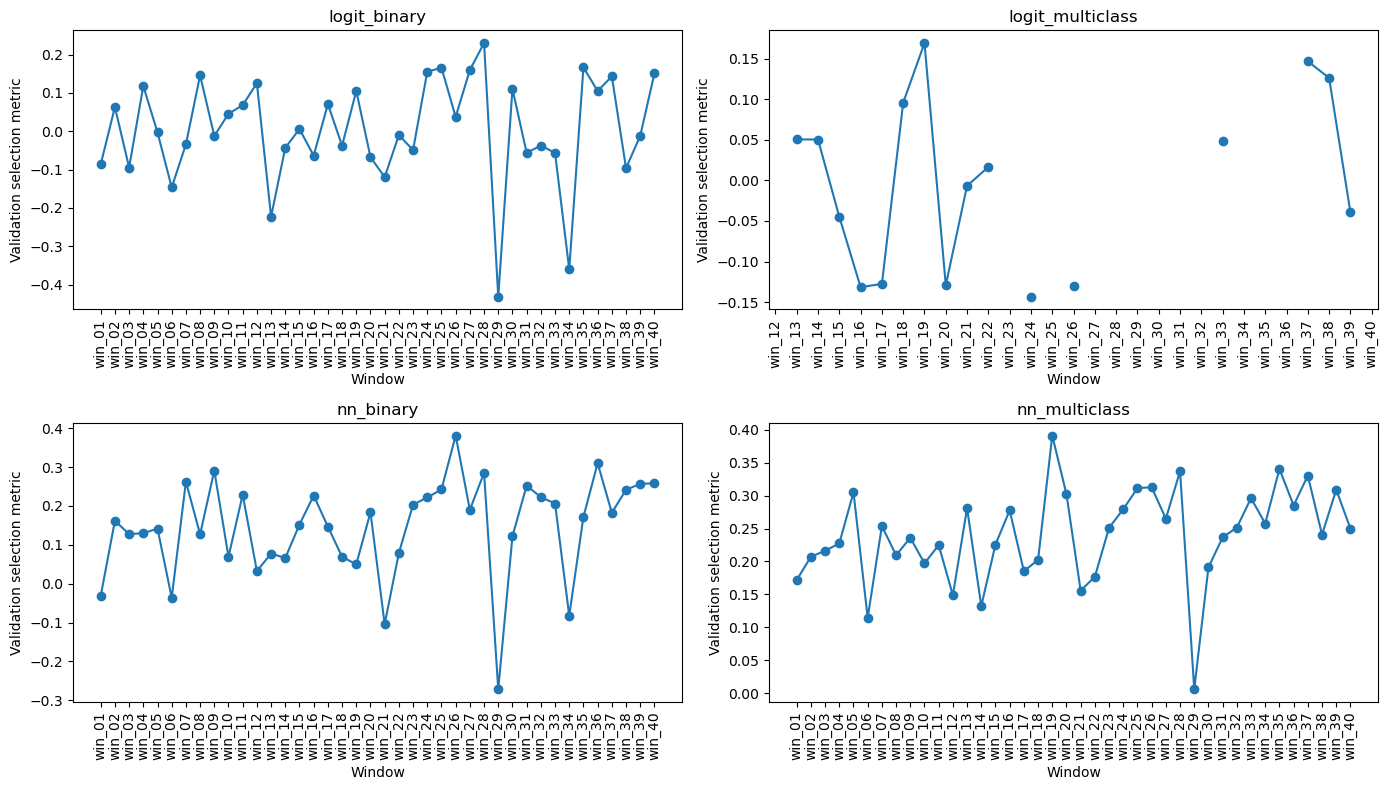

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=False)
axes = axes.ravel()

for ax, model_id in zip(axes, sorted(best_params_summary["model_id"].unique())):
    sub = best_params_summary[best_params_summary["model_id"] == model_id].sort_values("window_id").copy()
    ax.plot(sub["window_id"], sub["selection_metric"], marker="o")
    ax.set_title(model_id)
    ax.set_xlabel("Window")
    ax.set_ylabel("Validation selection metric")
    ax.tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()

### How to read the tuning output

- `tuning_summary` reports every candidate considered in every rolling window.
- `best_params_summary` reports only the winning candidate in each window.
- If a model repeatedly selects the same parameter values, the preferred complexity is stable.
- If the winning values jump around, the validation set is detecting changing conditions across time.
- The validation selection metric is the quantity the pipeline is explicitly optimizing before the final test is touched.


## 6. Model fit evaluation

This section evaluates the classification side of the project.

Interpretation guide:

- **Training accuracy much higher than validation and test accuracy** suggests overfitting.
- **Validation accuracy close to test accuracy** suggests the tuning process is generalizing well.
- In the multiclass models, the confusion matrices show whether the classifier is mostly predicting the neutral class $0$ or whether it meaningfully distinguishes $-1$, $0$, and $1$.
- For the binary models, a confusion matrix with very unbalanced predictions may indicate that the model is collapsing toward one side of the spread sign.


In [16]:
classification_summary = results["classification_summary"].copy()
confusion_summary = results["confusion_summary"].copy()

display(classification_summary.head())
display(confusion_summary.head())

,model_name,class_type,model_id,window_id,split,accuracy,n_obs,n_pred_0,n_true_0,n_pred_1,n_true_1,n_pred_minus_1,n_true_minus_1
0,logit,binary,logit_binary,win_01,train,0.5374,"1,258.0000",699.0000,651.0000,559.0000,607.0000,NaN,NaN
1,logit,binary,logit_binary,win_01,val,0.5397,63.0000,38.0000,27.0000,25.0000,36.0000,NaN,NaN
2,logit,binary,logit_binary,win_01,test,0.4754,61.0000,16.0000,30.0000,45.0000,31.0000,NaN,NaN
3,logit,binary,logit_binary,win_02,train,0.5374,"1,258.0000",684.0000,646.0000,574.0000,612.0000,NaN,NaN
4,logit,binary,logit_binary,win_02,val,0.5738,61.0000,10.0000,30.0000,51.0000,31.0000,NaN,NaN


,model_name,class_type,model_id,window_id,split,actual_label,pred_0,pred_1,pred_-1
0,logit,binary,logit_binary,win_01,train,actual_0,384,267,NaN
1,logit,binary,logit_binary,win_01,train,actual_1,315,292,NaN
2,logit,binary,logit_binary,win_01,val,actual_0,18,9,NaN
3,logit,binary,logit_binary,win_01,val,actual_1,20,16,NaN
4,logit,binary,logit_binary,win_01,test,actual_0,7,23,NaN


In [17]:
class_mean = (
    classification_summary
    .groupby(["model_id", "split"], as_index=False)
    .agg(
        mean_accuracy=("accuracy", "mean"),
        std_accuracy=("accuracy", "std"),
        n_windows=("window_id", "nunique"),
        mean_n_obs=("n_obs", "mean"),
    )
    .sort_values(["split", "mean_accuracy"], ascending=[True, False])
)

display(class_mean)

,model_id,split,mean_accuracy,std_accuracy,n_windows,mean_n_obs
3,logit_multiclass,test,0.6507,0.1803,40,62.9000
6,nn_binary,test,0.4939,0.0702,40,62.9000
0,logit_binary,test,0.4881,0.0642,40,62.9000
9,nn_multiclass,test,0.4572,0.1568,40,62.9000
7,nn_binary,train,0.7747,0.1042,40,"1,258.2500"
10,nn_multiclass,train,0.7721,0.0987,40,"1,258.2500"
4,logit_multiclass,train,0.6732,0.1104,40,"1,258.2500"
1,logit_binary,train,0.5420,0.0084,40,"1,258.2500"
8,nn_binary,val,0.7939,0.1111,40,62.9000
11,nn_multiclass,val,0.7824,0.1171,40,62.9000


In [18]:
class_pivot = class_mean.pivot(index="model_id", columns="split", values="mean_accuracy")
display(class_pivot.sort_index())

split,test,train,val
model_id,,,
logit_binary,0.4881,0.5420,0.5448
logit_multiclass,0.6507,0.6732,0.6550
nn_binary,0.4939,0.7747,0.7939
nn_multiclass,0.4572,0.7721,0.7824


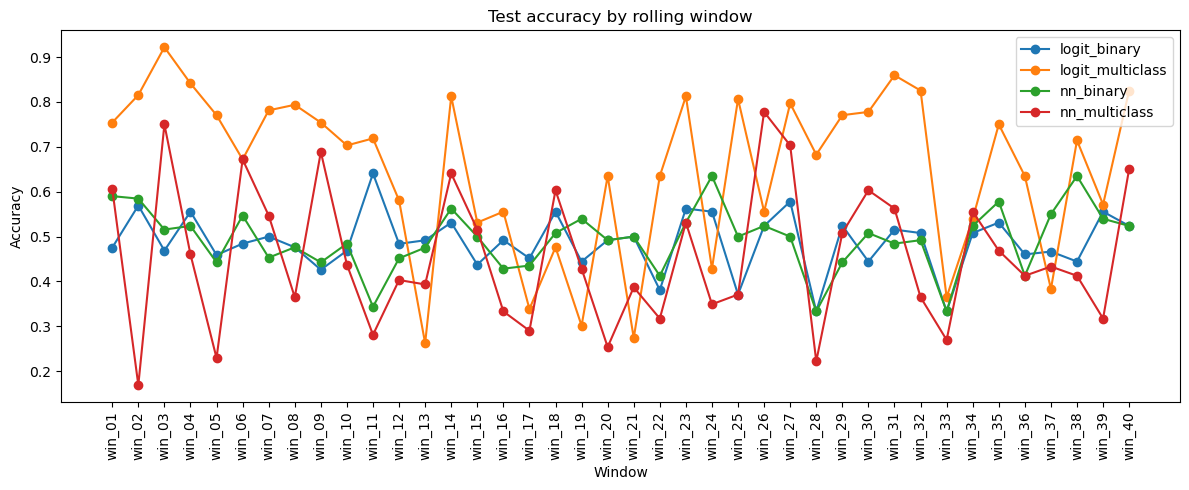

In [19]:
test_acc_by_window = (
    classification_summary[classification_summary["split"] == "test"]
    .sort_values(["model_id", "window_id"])
)

plt.figure(figsize=(12, 5))
for model_id, sub in test_acc_by_window.groupby("model_id"):
    plt.plot(sub["window_id"], sub["accuracy"], marker="o", linewidth=1.5, label=model_id)

plt.title("Test accuracy by rolling window")
plt.xlabel("Window")
plt.ylabel("Accuracy")
plt.xticks(rotation=90)
plt.legend()
plt.tight_layout()
plt.show()

In [20]:
def aggregated_confusion(confusion_summary, split="test"):
    pred_cols = [c for c in confusion_summary.columns if c.startswith("pred_")]
    out = {}
    for model_id, sub in confusion_summary[confusion_summary["split"] == split].groupby("model_id"):
        table = sub.groupby("actual_label")[pred_cols].sum()
        out[model_id] = table
    return out

agg_conf_test = aggregated_confusion(confusion_summary, split="test")
agg_conf_val = aggregated_confusion(confusion_summary, split="val")

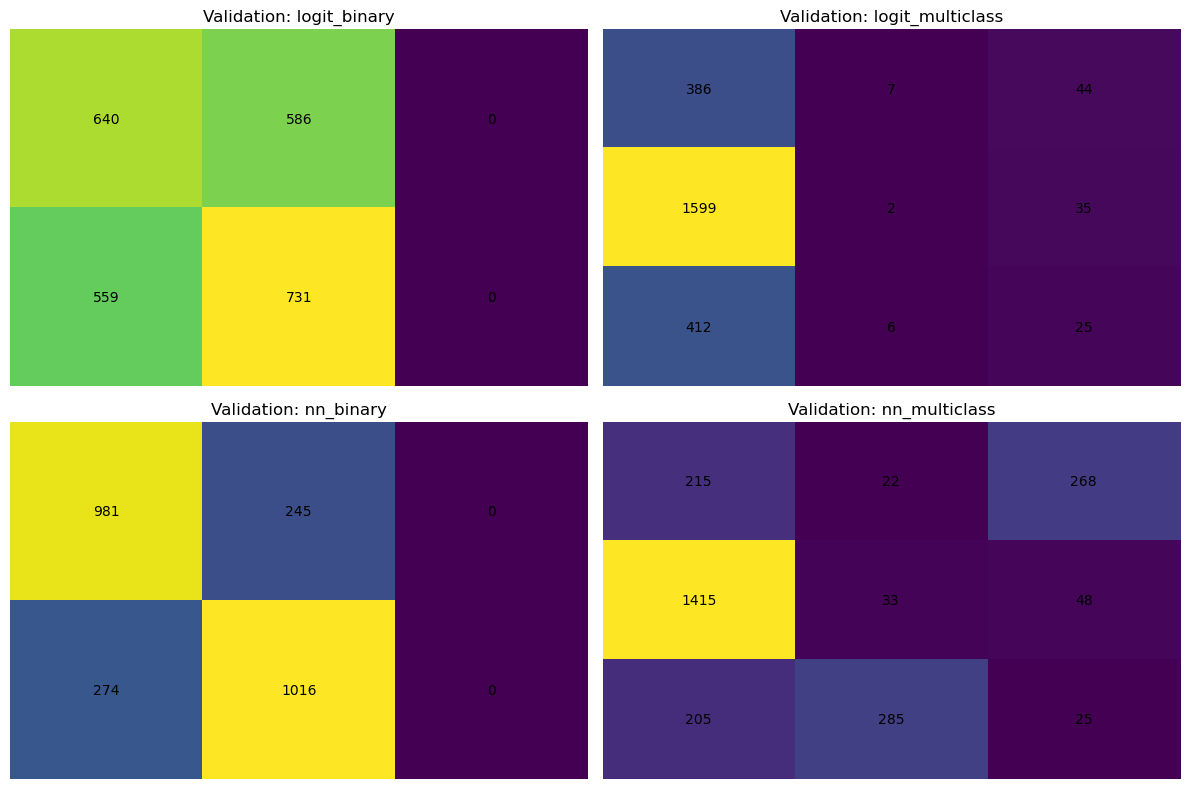

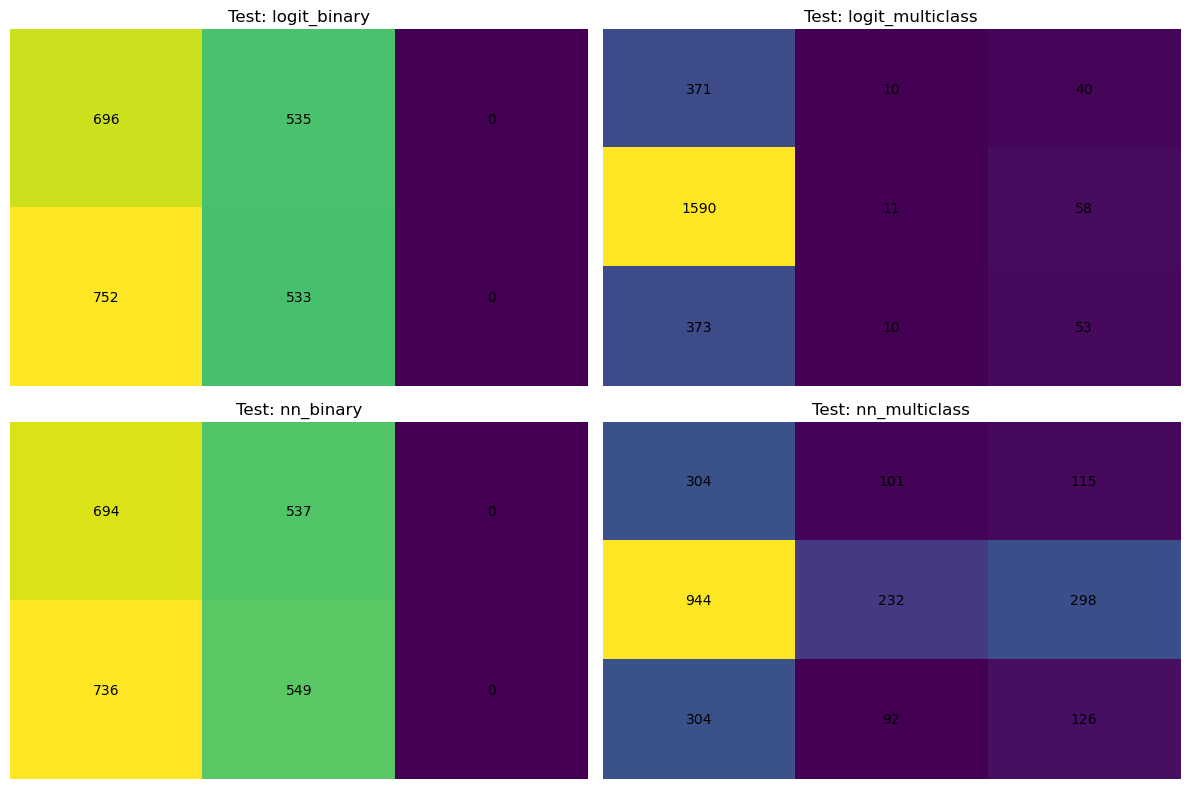

In [21]:
def plot_confusion_tables(conf_dict, title_prefix="", ncols=2, figsize=(12, 8)):
    items = list(conf_dict.items())
    n = len(items)
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = np.atleast_1d(axes).reshape(nrows, ncols)

    for ax in axes.flat:
        ax.axis("off")

    for ax, (model_id, table) in zip(axes.flat, items):
        arr = table.to_numpy(dtype=float)
        im = ax.imshow(arr, aspect="auto")
        ax.set_title(f"{title_prefix}{model_id}")
        ax.set_xticks(range(table.shape[1]))
        ax.set_xticklabels(table.columns, rotation=45, ha="right")
        ax.set_yticks(range(table.shape[0]))
        ax.set_yticklabels(table.index)

        for i in range(arr.shape[0]):
            for j in range(arr.shape[1]):
                ax.text(j, i, int(arr[i, j]), ha="center", va="center")

    plt.tight_layout()
    plt.show()

plot_confusion_tables(agg_conf_val, title_prefix="Validation: ")
plot_confusion_tables(agg_conf_test, title_prefix="Test: ")

### How to interpret the model-fit tables

- Start with the **test split**, not the train split. The test split is the final out-of-sample score after validation-based tuning.
- Then compare **validation vs test**. If they line up closely, tuning is behaving sensibly.
- Then compare **train vs validation**. A large drop from train to validation means the fitted model is too flexible relative to the available signal.
- In the multiclass confusion matrix, strong concentration in the `pred_0` column means the model is choosing to stay neutral frequently.
- In the binary setting, accuracy alone is not enough. A model can get moderate accuracy but still generate a weak trading rule if the correct calls occur on low-payoff days.


## 7. Portfolio performance evaluation

This section evaluates the trading side of the project.

Interpretation guide:

- **Cumulative return** tells you total growth over the relevant windows.
- **Mean return** and **volatility** summarize the daily return distribution.
- **Sharpe** measures reward per unit of risk.
- **Hit rate** is the fraction of days with positive strategy return.
- **Active rate** is especially important for multiclass models because the model can choose $0$ and not trade.
- **Alpha**, **beta**, and **information ratio** are reported relative to the benchmarks, so they describe whether the ML strategy is adding value beyond simpler rules.


In [22]:
portfolio_summary = results["portfolio_summary"].copy()
relative_summary = results["relative_summary"].copy()

display(portfolio_summary.head())
display(relative_summary.head())

,cumulative_return,mean_return,volatility,sharpe,hit_rate,n_obs,active_rate,model_name,class_type,model_id,window_id,split,portfolio_name
0,7.5086,0.0019,0.0179,0.1043,0.5366,"1,258.0000",1.0000,logit,binary,logit_binary,win_01,train,strategy_gross
1,6.9210,0.0018,0.0179,0.1010,0.5358,"1,258.0000",1.0000,logit,binary,logit_binary,win_01,train,strategy_net
2,-0.7315,-0.0009,0.0179,-0.0493,0.4825,"1,258.0000",NaN,logit,binary,logit_binary,win_01,train,benchmark_nvda_minus_tsla
3,1.4833,0.0009,0.0179,0.0493,0.5167,"1,258.0000",NaN,logit,binary,logit_binary,win_01,train,benchmark_tsla_minus_nvda
4,1.1229,0.0008,0.0179,0.0423,0.5016,"1,258.0000",1.0000,logit,binary,logit_binary,win_01,train,benchmark_mom21


,beta,alpha,information_ratio,model_name,class_type,model_id,window_id,split,strategy_name,benchmark_name
0,-0.2477,0.0016,0.0950,logit,binary,logit_binary,win_01,train,strategy_gross,benchmark_nvda_minus_tsla
1,0.1723,0.0017,0.0984,logit,binary,logit_binary,win_01,train,strategy_gross,benchmark_mom21
2,-0.0519,0.0018,0.1036,logit,binary,logit_binary,win_01,train,strategy_gross,benchmark_random_walk
3,-0.2476,0.0016,0.0917,logit,binary,logit_binary,win_01,train,strategy_net,benchmark_nvda_minus_tsla
4,0.1729,0.0017,0.0951,logit,binary,logit_binary,win_01,train,strategy_net,benchmark_mom21


In [23]:
strategy_only = portfolio_summary[portfolio_summary["portfolio_name"].isin(["strategy_gross", "strategy_net"])].copy()
benchmark_only = portfolio_summary[~portfolio_summary["portfolio_name"].isin(["strategy_gross", "strategy_net"])].copy()

strategy_table = (
    strategy_only
    .groupby(["model_id", "split", "portfolio_name"], as_index=False)
    .agg(
        mean_cumulative_return=("cumulative_return", "mean"),
        mean_mean_return=("mean_return", "mean"),
        mean_volatility=("volatility", "mean"),
        mean_sharpe=("sharpe", "mean"),
        mean_hit_rate=("hit_rate", "mean"),
        mean_active_rate=("active_rate", "mean"),
        n_windows=("window_id", "nunique"),
    )
    .sort_values(["split", "portfolio_name", "mean_sharpe"], ascending=[True, True, False])
)

benchmark_table = (
    benchmark_only
    .groupby(["portfolio_name", "split"], as_index=False)
    .agg(
        mean_cumulative_return=("cumulative_return", "mean"),
        mean_mean_return=("mean_return", "mean"),
        mean_volatility=("volatility", "mean"),
        mean_sharpe=("sharpe", "mean"),
        mean_hit_rate=("hit_rate", "mean"),
        n_windows=("window_id", "nunique"),
    )
    .sort_values(["split", "mean_sharpe"], ascending=[True, False])
)

display(Markdown("### Strategy summary"))
display(strategy_table)

display(Markdown("### Benchmark summary"))
display(benchmark_table)

### Strategy summary

,model_id,split,portfolio_name,mean_cumulative_return,mean_mean_return,mean_volatility,mean_sharpe,mean_hit_rate,mean_active_rate,n_windows
18,nn_multiclass,test,strategy_gross,-0.0106,-0.0002,0.0094,-0.0031,0.1968,0.3833,40
12,nn_binary,test,strategy_gross,-0.0311,-0.0006,0.0180,-0.0248,0.4935,1.0000,40
0,logit_binary,test,strategy_gross,-0.0386,-0.0007,0.0180,-0.0335,0.4877,1.0000,40
6,logit_multiclass,test,strategy_gross,-0.0092,-0.0002,0.0020,-0.0701,0.0325,0.0739,40
19,nn_multiclass,test,strategy_net,-0.0143,-0.0003,0.0094,-0.0095,0.1956,0.3833,40
13,nn_binary,test,strategy_net,-0.0367,-0.0007,0.0180,-0.0301,0.4903,1.0000,40
1,logit_binary,test,strategy_net,-0.0420,-0.0007,0.0180,-0.0370,0.4842,1.0000,40
7,logit_multiclass,test,strategy_net,-0.0095,-0.0002,0.0020,-0.0740,0.0321,0.0739,40
14,nn_binary,train,strategy_gross,"94,780.5345",0.0074,0.0162,0.4701,0.7746,1.0000,40
20,nn_multiclass,train,strategy_gross,"4,533.2903",0.0042,0.0121,0.3201,0.2048,0.2429,40


### Benchmark summary

,portfolio_name,split,mean_cumulative_return,mean_mean_return,mean_volatility,mean_sharpe,mean_hit_rate,n_windows
0,benchmark_mom21,test,0.0483,0.0007,0.0180,0.0407,0.5183,40
3,benchmark_nvda_minus_tsla,test,0.0264,0.0003,0.0180,0.0249,0.5107,40
6,benchmark_random_walk,test,-0.0093,-0.0002,0.0180,-0.0140,0.4886,40
9,benchmark_tsla_minus_nvda,test,-0.0131,-0.0003,0.0180,-0.0249,0.4889,40
1,benchmark_mom21,train,1.1196,0.0007,0.0180,0.0402,0.5144,40
4,benchmark_nvda_minus_tsla,train,0.0033,0.0000,0.0180,0.0010,0.5053,40
10,benchmark_tsla_minus_nvda,train,-0.0314,-0.0000,0.0180,-0.0010,0.4945,40
7,benchmark_random_walk,train,-0.5392,-0.0005,0.0180,-0.0265,0.4880,40
2,benchmark_mom21,val,0.0551,0.0008,0.0181,0.0469,0.5211,40
5,benchmark_nvda_minus_tsla,val,0.0325,0.0004,0.0180,0.0302,0.5127,40


In [24]:
test_strategy_rank = (
    strategy_table[
        (strategy_table["split"] == "test") &
        (strategy_table["portfolio_name"] == "strategy_net")
    ]
    .sort_values("mean_sharpe", ascending=False)
    .reset_index(drop=True)
)

display(Markdown("### Test ranking: net strategy"))
display(test_strategy_rank)

### Test ranking: net strategy

,model_id,split,portfolio_name,mean_cumulative_return,mean_mean_return,mean_volatility,mean_sharpe,mean_hit_rate,mean_active_rate,n_windows
0,nn_multiclass,test,strategy_net,-0.0143,-0.0003,0.0094,-0.0095,0.1956,0.3833,40
1,nn_binary,test,strategy_net,-0.0367,-0.0007,0.0180,-0.0301,0.4903,1.0000,40
2,logit_binary,test,strategy_net,-0.0420,-0.0007,0.0180,-0.0370,0.4842,1.0000,40
3,logit_multiclass,test,strategy_net,-0.0095,-0.0002,0.0020,-0.0740,0.0321,0.0739,40


In [25]:
relative_test = (
    relative_summary[relative_summary["split"] == "test"]
    .groupby(["model_id", "strategy_name", "benchmark_name"], as_index=False)
    .agg(
        mean_beta=("beta", "mean"),
        mean_alpha=("alpha", "mean"),
        mean_information_ratio=("information_ratio", "mean"),
        n_windows=("window_id", "nunique"),
    )
    .sort_values(["strategy_name", "benchmark_name", "mean_information_ratio"], ascending=[True, True, False])
)

display(relative_test)

,model_id,strategy_name,benchmark_name,mean_beta,mean_alpha,mean_information_ratio,n_windows
18,nn_multiclass,strategy_gross,benchmark_mom21,-0.0689,0.0002,0.0243,40
12,nn_binary,strategy_gross,benchmark_mom21,-0.1258,-0.0002,-0.0129,40
0,logit_binary,strategy_gross,benchmark_mom21,-0.1366,-0.0003,-0.0243,40
6,logit_multiclass,strategy_gross,benchmark_mom21,0.0023,-0.0001,-0.0609,40
19,nn_multiclass,strategy_gross,benchmark_nvda_minus_tsla,-0.0402,0.0002,0.0382,40
13,nn_binary,strategy_gross,benchmark_nvda_minus_tsla,-0.1608,-0.0000,0.0017,40
1,logit_binary,strategy_gross,benchmark_nvda_minus_tsla,-0.1447,-0.0002,-0.0127,40
7,logit_multiclass,strategy_gross,benchmark_nvda_minus_tsla,-0.0315,-0.0001,-0.0788,40
20,nn_multiclass,strategy_gross,benchmark_random_walk,-0.0243,-0.0003,-0.0066,40
2,logit_binary,strategy_gross,benchmark_random_walk,-0.0204,-0.0007,-0.0353,40


### How to interpret the portfolio tables

- Use the **net** strategy as the primary ranking because it includes transaction costs.
- Compare **train**, **validation**, and **test** Sharpe. A strategy that looks excellent only in train but weak in validation and test is not reliable.
- A multiclass model may have lower active rate but better net Sharpe if the neutral class filters out poor trades.
- A positive average alpha against a benchmark means the strategy is beating that benchmark on a risk-adjusted residual basis.
- A high information ratio means the strategy's excess return over the benchmark is more stable.


## 8. Wealth-curve plots

Because the rolling design uses overlapping training windows, a single calendar-time training wealth path is not well-defined.  
So the notebook uses two plotting conventions:

1. **Calendar-time stitched wealth** for the non-overlapping test windows.  
   This is the cleanest out-of-sample cumulative path.

2. **Average within-window wealth by event time** for train, validation, and test.  
   This compares the typical trajectory inside each split and avoids mixing overlapping windows into a misleading calendar-time train path.


In [26]:
predictions = results["predictions"].copy()

display(predictions.head())
print(predictions[["model_id", "split"]].drop_duplicates().sort_values(["model_id", "split"]).to_string(index=False))

,date,ret_a_next,ret_b_next,spread_t,spread_next,mom21_diff,model_name,class_type,model_id,window_id,split,abs_threshold,multiclass_quantile,y_true,y_pred,signal,is_active,turnover,strategy_gross,strategy_net,prob_0,prob_1,benchmark_nvda_minus_tsla,benchmark_tsla_minus_nvda,benchmark_mom21_signal,benchmark_mom21,benchmark_random_walk_signal,benchmark_random_walk,prob_-1
0,2010-09-28,-0.0076,0.0271,-0.0444,-0.0347,0.0966,logit,binary,logit_binary,win_01,train,NaN,NaN,0,0,-1,1,0.0000,0.0174,0.0174,0.5902,0.4098,-0.0174,0.0174,1,-0.0174,-1,0.0174,NaN
1,2010-09-29,-0.0167,-0.0717,-0.0347,0.0550,0.1262,logit,binary,logit_binary,win_01,train,NaN,NaN,1,0,-1,1,0.0000,-0.0275,-0.0275,0.5730,0.4270,0.0275,-0.0275,1,0.0275,-1,-0.0275,NaN
2,2010-09-30,-0.0284,0.0096,0.0550,-0.0380,0.2053,logit,binary,logit_binary,win_01,train,NaN,NaN,0,0,-1,1,0.0000,0.0190,0.0190,0.5632,0.4368,-0.0190,0.0190,1,-0.0190,1,-0.0190,NaN
3,2010-10-01,-0.0097,0.0189,-0.0380,-0.0286,0.2000,logit,binary,logit_binary,win_01,train,NaN,NaN,0,0,-1,1,0.0000,0.0143,0.0143,0.5697,0.4303,-0.0143,0.0143,1,-0.0143,-1,0.0143,NaN
4,2010-10-04,0.0071,0.0062,-0.0286,0.0009,0.1778,logit,binary,logit_binary,win_01,train,NaN,NaN,1,0,-1,1,0.0000,-0.0005,-0.0005,0.5743,0.4257,0.0005,-0.0005,1,0.0005,-1,-0.0005,NaN


        model_id split
    logit_binary  test
    logit_binary train
    logit_binary   val
logit_multiclass  test
logit_multiclass train
logit_multiclass   val
       nn_binary  test
       nn_binary train
       nn_binary   val
   nn_multiclass  test
   nn_multiclass train
   nn_multiclass   val


In [27]:
def stitched_split_returns(predictions, split="test", strategy_col="strategy_net"):
    sub = predictions[predictions["split"] == split].copy()
    sub = sub.sort_values(["model_id", "date"])

    stitched = []
    for model_id, g in sub.groupby("model_id"):
        temp = g[["date", strategy_col]].drop_duplicates(subset=["date"]).sort_values("date").copy()
        temp["model_id"] = model_id
        stitched.append(temp)

    return pd.concat(stitched, ignore_index=True)


def plot_calendar_time_wealth(predictions, split="test", strategy_col="strategy_net", include_benchmarks=True):
    stitched = stitched_split_returns(predictions, split=split, strategy_col=strategy_col)

    plt.figure(figsize=(12, 5))
    for model_id, sub in stitched.groupby("model_id"):
        plt.plot(sub["date"], wealth_index(sub[strategy_col]), linewidth=2, label=model_id)

    if include_benchmarks:
        bench_cols = [
            "benchmark_nvda_minus_tsla",
            "benchmark_mom21",
            "benchmark_random_walk",
        ]
        for bench_col in bench_cols:
            bench = (
                predictions[predictions["split"] == split][["date", bench_col]]
                .drop_duplicates(subset=["date"])
                .sort_values("date")
            )
            plt.plot(bench["date"], wealth_index(bench[bench_col]), linestyle="--", label=bench_col)

    plt.title(f"Calendar-time stitched wealth: {split} / {strategy_col}")
    plt.xlabel("Date")
    plt.ylabel("Wealth index")
    plt.legend()
    plt.tight_layout()
    plt.show()

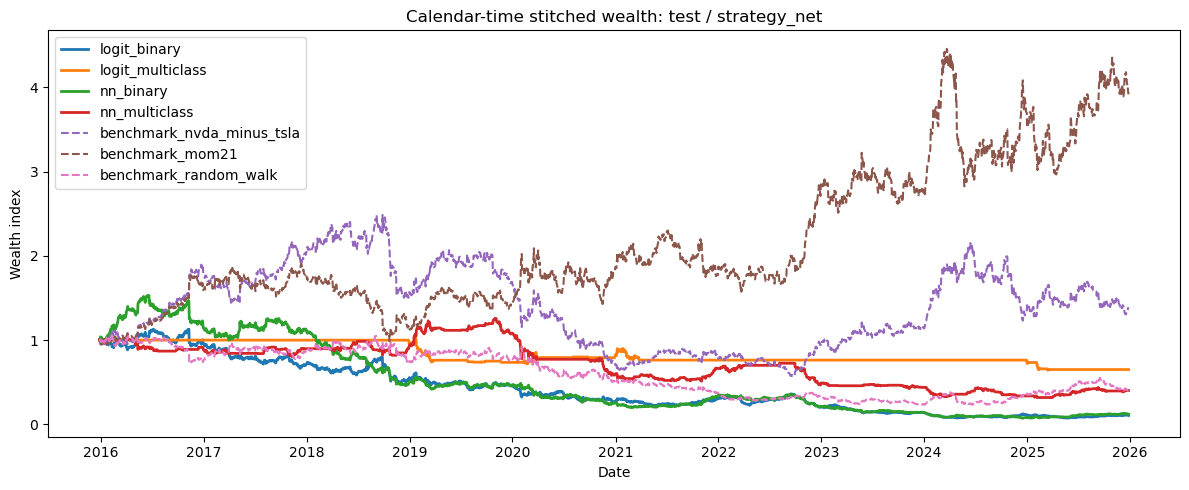

In [28]:
plot_calendar_time_wealth(predictions, split="test", strategy_col="strategy_net", include_benchmarks=True)

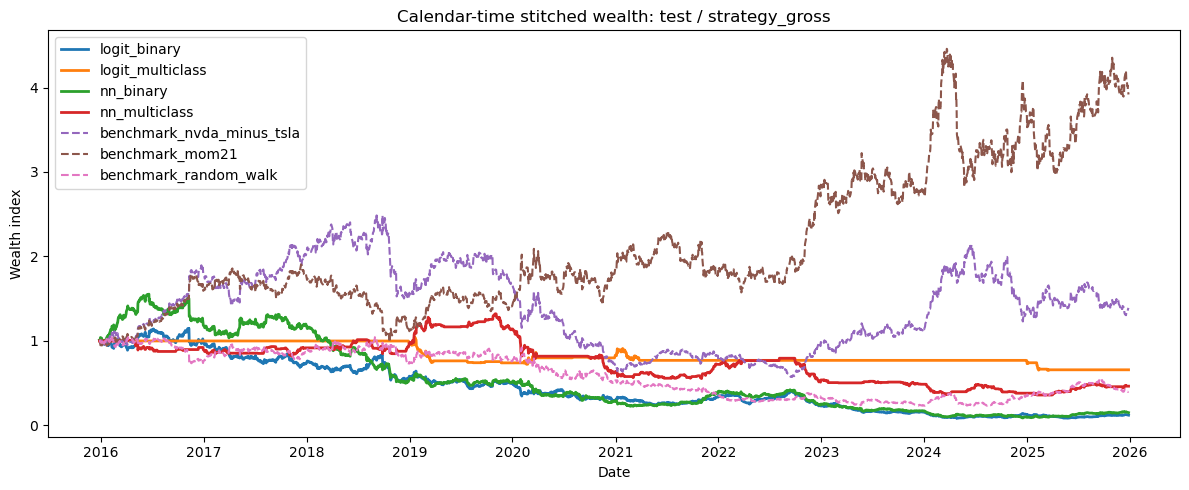

In [29]:
plot_calendar_time_wealth(predictions, split="test", strategy_col="strategy_gross", include_benchmarks=True)

In [30]:
def average_event_time_wealth(predictions, split="train", return_col="strategy_net", benchmark=False, model_id=None):
    if benchmark:
        sub = predictions[predictions["split"] == split][["window_id", "date", return_col]].drop_duplicates().copy()
        grouping_keys = ["window_id"]
    else:
        sub = predictions[(predictions["split"] == split) & (predictions["model_id"] == model_id)][["window_id", "date", return_col]].copy()
        grouping_keys = ["window_id"]

    sub = sub.sort_values(grouping_keys + ["date"]).copy()
    sub["event_time"] = sub.groupby(grouping_keys).cumcount()
    sub["wealth"] = sub.groupby(grouping_keys)[return_col].transform(lambda x: wealth_index(x).to_numpy())

    out = sub.groupby("event_time", as_index=False).agg(mean_wealth=("wealth", "mean"))
    return out


def plot_event_time_wealth(predictions, split="train", strategy_col="strategy_net", include_benchmarks=True):
    plt.figure(figsize=(12, 5))

    for model_id in sorted(predictions["model_id"].unique()):
        avg = average_event_time_wealth(
            predictions,
            split=split,
            return_col=strategy_col,
            benchmark=False,
            model_id=model_id,
        )
        plt.plot(avg["event_time"], avg["mean_wealth"], linewidth=2, label=model_id)

    if include_benchmarks:
        for bench_col in ["benchmark_nvda_minus_tsla", "benchmark_mom21", "benchmark_random_walk"]:
            avg_bench = average_event_time_wealth(
                predictions,
                split=split,
                return_col=bench_col,
                benchmark=True,
            )
            plt.plot(avg_bench["event_time"], avg_bench["mean_wealth"], linestyle="--", label=bench_col)

    plt.title(f"Average within-window wealth: {split} / {strategy_col}")
    plt.xlabel("Event time within split")
    plt.ylabel("Average wealth index")
    plt.legend()
    plt.tight_layout()
    plt.show()

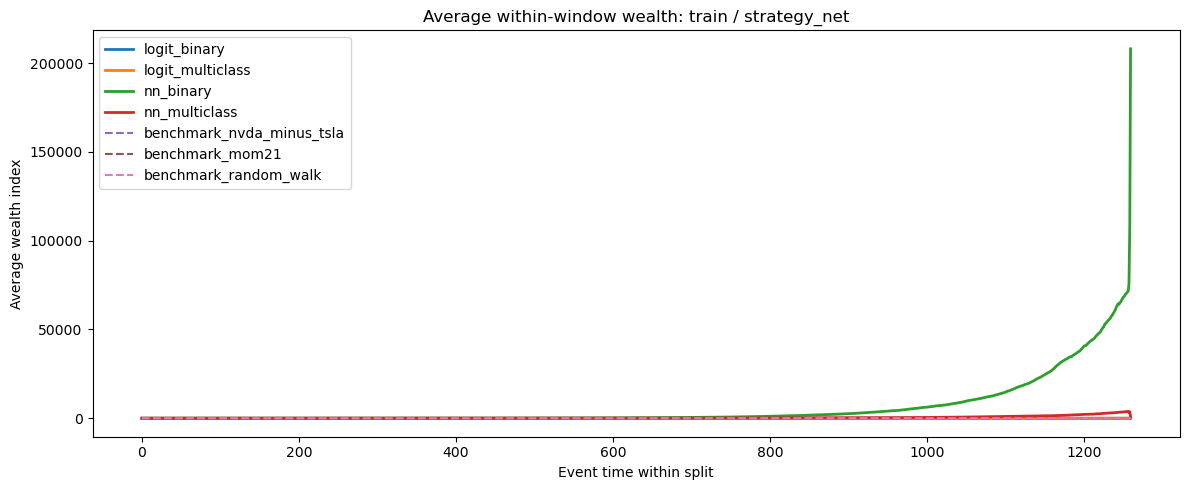

In [31]:
plot_event_time_wealth(predictions, split="train", strategy_col="strategy_net", include_benchmarks=True)

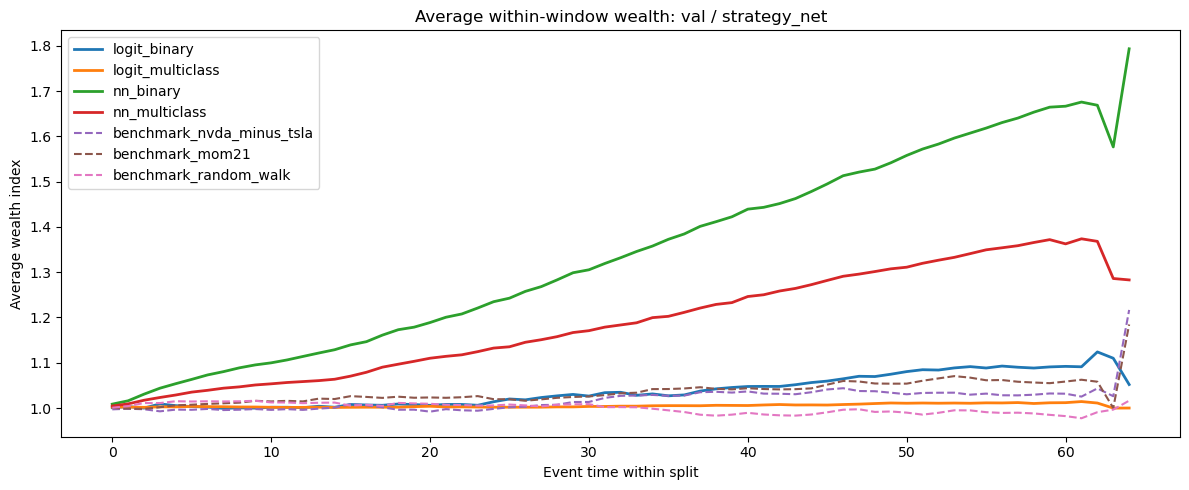

In [32]:
plot_event_time_wealth(predictions, split="val", strategy_col="strategy_net", include_benchmarks=True)

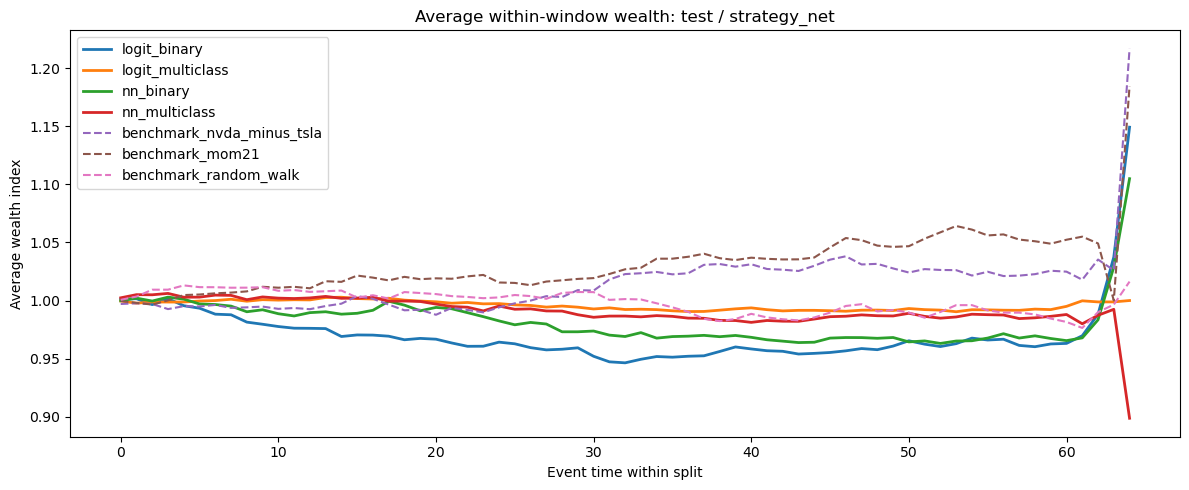

In [33]:
plot_event_time_wealth(predictions, split="test", strategy_col="strategy_net", include_benchmarks=True)

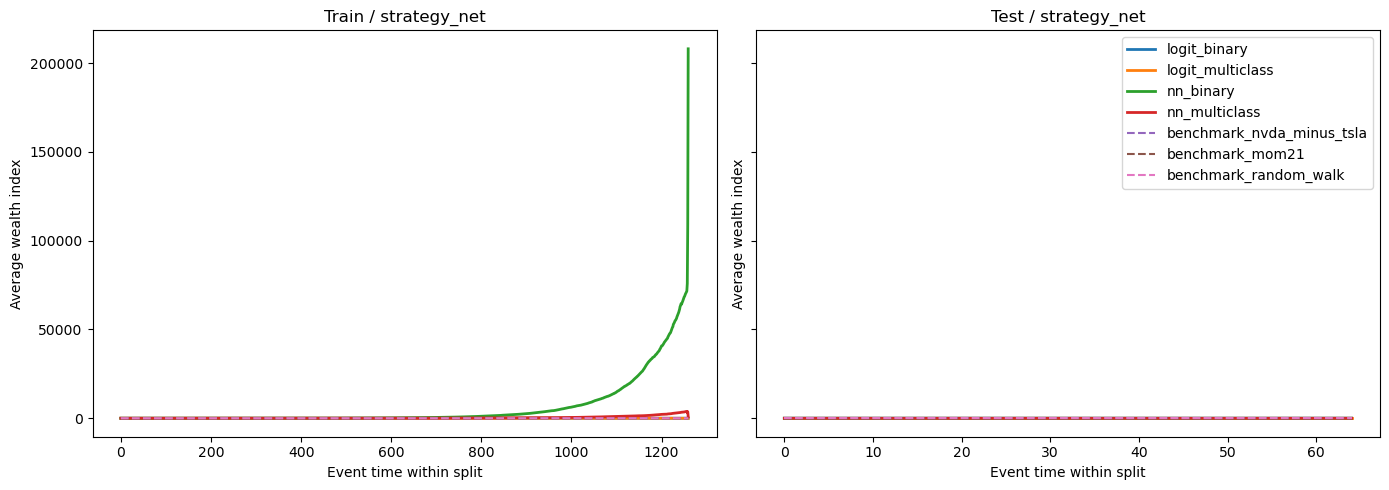

In [34]:
def plot_train_test_side_by_side(predictions, strategy_col="strategy_net"):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

    for ax, split in zip(axes, ["train", "test"]):
        for model_id in sorted(predictions["model_id"].unique()):
            avg = average_event_time_wealth(
                predictions,
                split=split,
                return_col=strategy_col,
                benchmark=False,
                model_id=model_id,
            )
            ax.plot(avg["event_time"], avg["mean_wealth"], linewidth=2, label=model_id)

        for bench_col in ["benchmark_nvda_minus_tsla", "benchmark_mom21", "benchmark_random_walk"]:
            avg_bench = average_event_time_wealth(
                predictions,
                split=split,
                return_col=bench_col,
                benchmark=True,
            )
            ax.plot(avg_bench["event_time"], avg_bench["mean_wealth"], linestyle="--", label=bench_col)

        ax.set_title(f"{split.capitalize()} / {strategy_col}")
        ax.set_xlabel("Event time within split")
        ax.set_ylabel("Average wealth index")

    axes[1].legend(loc="best")
    plt.tight_layout()
    plt.show()

plot_train_test_side_by_side(predictions, strategy_col="strategy_net")

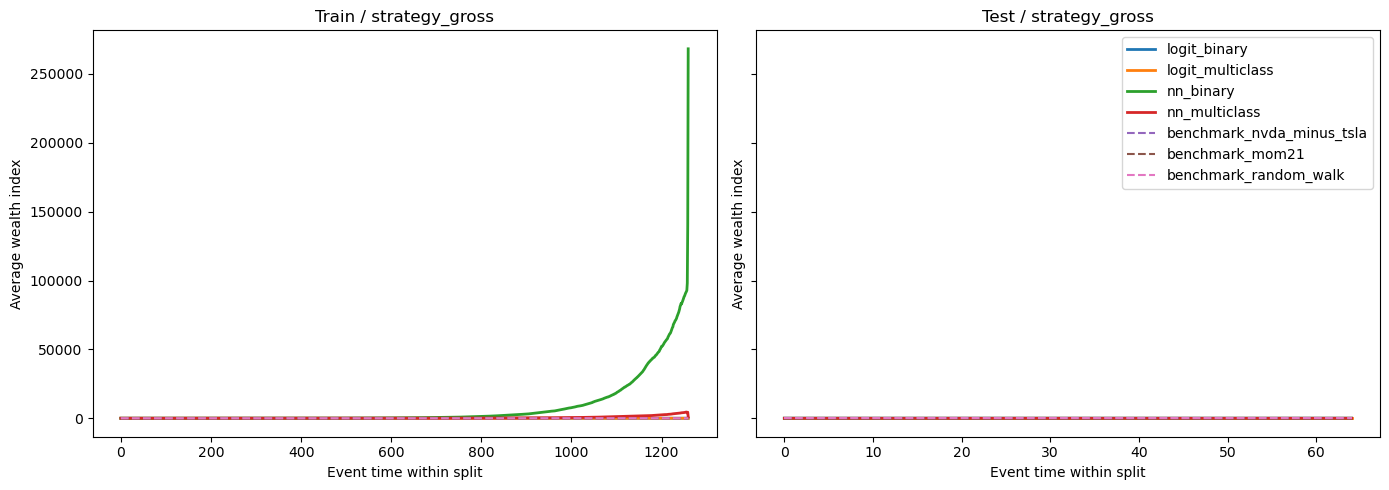

In [35]:
plot_train_test_side_by_side(predictions, strategy_col="strategy_gross")

### How to interpret the wealth plots

- The **stitched test wealth** plot is the primary out-of-sample cumulative-performance graph.
- The **event-time train, validation, and test** plots let you compare how performance behaves inside a typical rolling window.
- If train wealth rises strongly but test wealth is flat, the strategy is overfit.
- If validation and test wealth look qualitatively similar, the tuning stage is likely transferring well.
- If a model dominates in gross returns but not in net returns, turnover and transaction costs are eroding the edge.


## 9. Coefficient inspection for logistic regression

The logistic-regression coefficient tables help interpret which engineered feature differences are systematically associated with the predicted spread direction.

Interpretation guide:

- positive coefficient: higher NVDA-minus-TSLA feature difference increases the tendency toward the corresponding class,
- negative coefficient: higher NVDA-minus-TSLA feature difference decreases the tendency toward the corresponding class,
- coefficient stability across windows matters more than any single-window estimate.


In [36]:
coef_summary = results.get("coefficient_summary", None)

if coef_summary is None:
    print("No coefficient summary returned.")
else:
    display(coef_summary.head())

    coef_mean = (
        coef_summary
        .groupby(["model_id", "class_label", "feature"], as_index=False)
        .agg(mean_coef=("coef", "mean"))
    )

    for model_id in sorted(coef_mean["model_id"].unique()):
        display(Markdown(f"### Mean coefficients: `{model_id}`"))
        display(
            coef_mean[coef_mean["model_id"] == model_id]
            .sort_values(["class_label", "mean_coef"], ascending=[True, False])
        )

,model_name,class_type,model_id,window_id,class_label,feature,coef
0,logit,binary,logit_binary,win_01,1,op_margin_diff,0.9211
1,logit,binary,logit_binary,win_01,1,net_margin_diff,-0.9398
2,logit,binary,logit_binary,win_01,1,leverage_diff,0.1088
3,logit,binary,logit_binary,win_01,1,cash_ratio_diff,-0.0337
4,logit,binary,logit_binary,win_01,1,rnd_intensity_diff,-0.1085


### Mean coefficients: `logit_binary`

,model_id,class_label,feature,mean_coef
0,logit_binary,1,asset_turnover_diff,0.0698
12,logit_binary,1,rsi14_diff,0.0617
2,logit_binary,1,cash_ratio_diff,0.0420
14,logit_binary,1,vol_shock20_diff,0.0409
9,logit_binary,1,net_margin_diff,0.0403
3,logit_binary,1,leverage_diff,0.0281
1,logit_binary,1,capex_intensity_diff,0.0098
8,logit_binary,1,mom63_diff,0.0049
6,logit_binary,1,mom21_diff,-0.0063
5,logit_binary,1,ma_gap20_diff,-0.0073


### Mean coefficients: `logit_multiclass`

,model_id,class_label,feature,mean_coef
19,logit_multiclass,-1,log_mcap_diff,0.0867
25,logit_multiclass,-1,op_margin_diff,0.0498
20,logit_multiclass,-1,ma_gap20_diff,0.0430
22,logit_multiclass,-1,mom5_diff,0.0238
26,logit_multiclass,-1,rnd_intensity_diff,0.0136
17,logit_multiclass,-1,cash_ratio_diff,0.0010
21,logit_multiclass,-1,mom21_diff,-0.0040
29,logit_multiclass,-1,vol_shock20_diff,-0.0162
16,logit_multiclass,-1,capex_intensity_diff,-0.0374
23,logit_multiclass,-1,mom63_diff,-0.0425


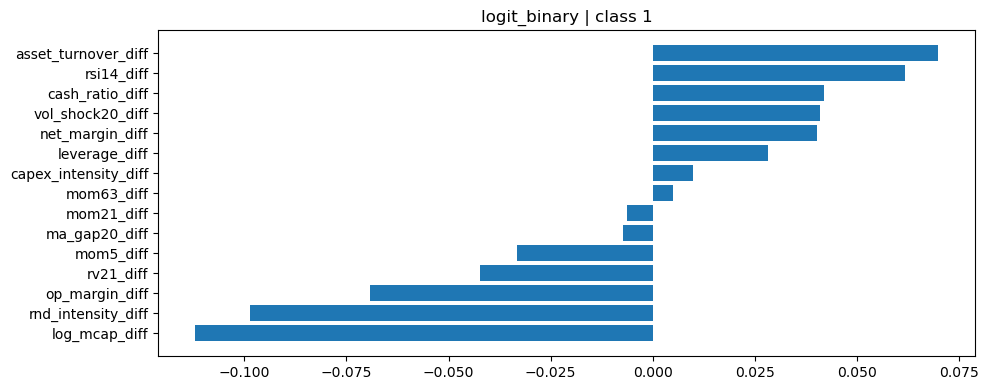

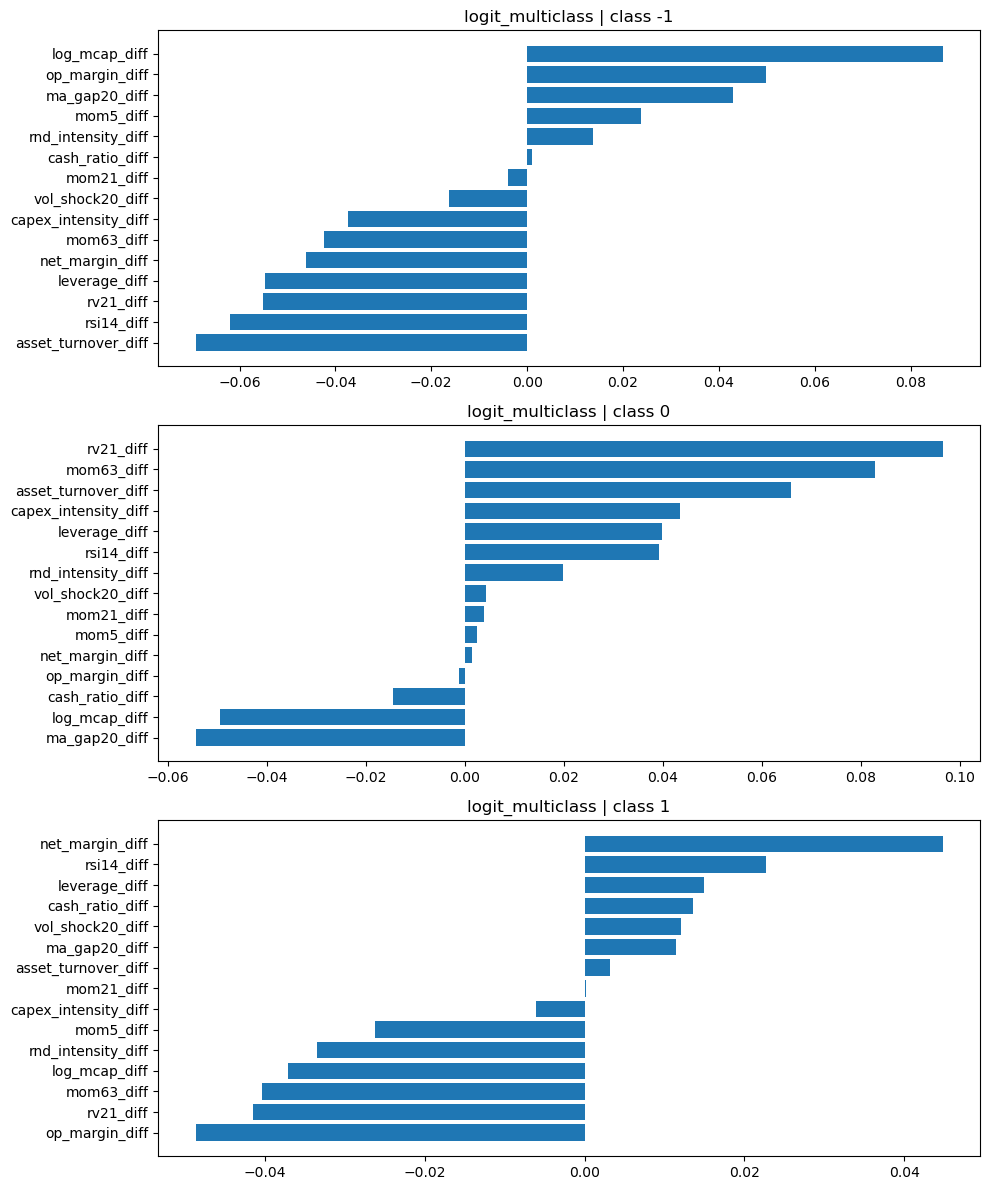

In [37]:
if coef_summary is not None:
    for model_id in sorted(coef_summary["model_id"].unique()):
        temp = (
            coef_summary[coef_summary["model_id"] == model_id]
            .groupby(["class_label", "feature"], as_index=False)
            .agg(mean_coef=("coef", "mean"))
        )

        class_labels = sorted(temp["class_label"].unique())
        fig, axes = plt.subplots(len(class_labels), 1, figsize=(10, 4 * len(class_labels)))
        axes = np.atleast_1d(axes)

        for ax, class_label in zip(axes, class_labels):
            sub = temp[temp["class_label"] == class_label].sort_values("mean_coef")
            ax.barh(sub["feature"], sub["mean_coef"])
            ax.set_title(f"{model_id} | class {class_label}")

        plt.tight_layout()
        plt.show()

## 10. Final output tables already written by the pipeline

In [38]:
output_tables = ROOT / "outputs" / "tables"
output_figures = ROOT / "outputs" / "figures"
output_models = ROOT / "outputs" / "models"

print("Tables folder :", output_tables)
print("Figures folder:", output_figures)
print("Models folder :", output_models)

print("\nTables:")
for p in sorted(output_tables.glob("*")):
    print(" -", p.name)

print("\nFigures:")
for p in sorted(output_figures.glob("*")):
    print(" -", p.name)

print("\nModels:")
for p in sorted(output_models.glob("*")):
    print(" -", p.name)

Tables folder : /Users/jimmyzheng0516/Desktop/Course-Winter-2026/FINM33160/ML-Group-Project/outputs/tables
Figures folder: /Users/jimmyzheng0516/Desktop/Course-Winter-2026/FINM33160/ML-Group-Project/outputs/figures
Models folder : /Users/jimmyzheng0516/Desktop/Course-Winter-2026/FINM33160/ML-Group-Project/outputs/models

Tables:
 - best_params_summary_all_models.csv
 - best_params_summary_logit_binary.csv
 - best_params_summary_logit_multiclass.csv
 - best_params_summary_nn_binary.csv
 - best_params_summary_nn_multiclass.csv
 - classification_metrics.csv
 - classification_metrics_logit.csv
 - classification_summary_all_models.csv
 - classification_summary_logit_binary.csv
 - classification_summary_logit_multiclass.csv
 - classification_summary_nn_binary.csv
 - classification_summary_nn_multiclass.csv
 - coefficients_all_models.csv
 - coefficients_logit_binary.csv
 - coefficients_logit_multiclass.csv
 - confusion_summary_all_models.csv
 - confusion_summary_logit_binary.csv
 - confusion_